# Generating synthetic 5-minute equity sessions with a wavelet DDPM

A reproduction of Takahashi & Mizuno, *Generation of synthetic financial time series by
diffusion models* ([arXiv:2410.18897](https://arxiv.org/abs/2410.18897), *Quantitative
Finance* **25**:1507–1516), moved from the paper's 1-minute AAPL history to 5-minute bars
across a cross-section of US equities.

The method in one sentence: take a trading session, write each of its three channels
(log return, spread, volume) as a stack of wavelet coefficient planes, treat that stack as
an RGB **image**, and train an ordinary image DDPM on it — so that "generate a plausible
trading day" becomes "generate a plausible picture".

### How to read this notebook

Per `CLAUDE.md` non-negotiable #1, the split between what is written out here and what is
imported is deliberate and not negotiable:

| | |
|---|---|
| **Written inline** | the mechanism — mirror-expansion, the Haar MODWT and its inverse, the sign-preserving power transform, the diffusion schedules, $q(x_t \mid x_0)$, the loss, the UNet, the training loop, the reverse sampler |
| **Imported from `src.diffmodel`** | the supporting cast — fixture loading, the fitted `Codec`, per-level standardisation, DataLoader plumbing, checkpoint I/O, the stylized-fact metrics |

(`src/diffmodel` has no plotting module, so the matplotlib below is written here too. It is
presentation rather than mechanism, and nothing in this notebook's argument depends on it.)

`src/diffmodel` is the *tested* copy (see `tests/`); this notebook is the *exposition*.
They are supposed to be the same code. Rather than asking you to take that on faith, each
inline block below is followed by an executed assertion that it agrees with its `src`
counterpart exactly — the transform, the wavelet, the schedules and $q(x_t \mid x_0)$, the
UNet's weights and forward pass, the loss at all three loss types, the EMA, the validation
loss, and the reverse sampler. **A divergence between the two is a bug, not a variation**,
and those assertions are how a bug would announce itself.

One block is deliberately *not* asserted: the epoch loop in §8. Comparing it against
`train.train()` would mean training the model a second time to produce one boolean, so it is
checked through its parts — every function it calls is asserted individually — and read
side by side rather than run side by side. §11 repeats that caveat where the evidence is
summarised.

### How to run it

The preset comes from `config.auto_config()`, which returns `FULL` on a CUDA machine and
`SMOKE` everywhere else. That is the whole point: **this file is not edited between the
local run and the Colab run.** Locally it proves the code path; on Colab it trains the
model. Read the closing section before believing anything about sample quality.

Nothing this notebook prints is a wall clock, so a re-execution reproduces the committed
outputs byte for byte — `CLAUDE.md` non-negotiable #4, checkable rather than asserted:

```
jupyter nbconvert --to notebook --execute \\
    --output /tmp/rerun.ipynb notebooks/01_wavelet_ddpm.ipynb
python notebooks/canonicalise.py /tmp/rerun.ipynb
cmp /tmp/rerun.ipynb notebooks/01_wavelet_ddpm.ipynb
```

`canonicalise.py` removes the two things `nbconvert` itself writes that are timing-dependent
and are not notebook content — per-cell execution timestamps, and whether a cell's stdout
happened to arrive in one chunk or two. It never touches output *text*. The compare succeeds
on a machine that already holds `checkpoints/smoke_latest.pt`; from a clean clone §8 trains
instead of loading, and says so in its own output.

In [1]:
"""Environment, imports, and the one global seed everything else forks from."""
from __future__ import annotations

import copy
import math
import sys
import time
import warnings
from dataclasses import replace
from pathlib import Path

# Locate the repo root by walking up until src/diffmodel appears, so the notebook
# works whether it is launched from notebooks/, from the repo root, or from a
# fresh `git clone` on Colab.
ROOT = Path.cwd().resolve()
while not (ROOT / "src" / "diffmodel").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn

# --- supporting code, imported (see the table above) ---
from diffmodel.config import (
    BARS_PER_DAY, CHANNELS, CHECKPOINTS, IMAGE_COLS, IMAGE_ROWS, N_LEVELS,
    PADDED_LEN, auto_config, pick_device,
)
from diffmodel.data import build_day_images
from diffmodel.pipeline import Codec, prepare
from diffmodel.seeding import ROOT_SEED, fork, seed_everything, torch_generator
from diffmodel.transform import DayTransform
from diffmodel.train import History, make_loader, save_checkpoint
from diffmodel.wavelet import apply_level_stats, fit_level_stats, invert_level_stats
from diffmodel import evaluate as ev

# --- the src copies of the MECHANISM, imported under aliases and used for one
# --- purpose only: proving the inline versions below are faithful mirrors.
from diffmodel import ddpm as src_ddpm
from diffmodel import train as src_train
from diffmodel import transform as src_transform
from diffmodel import wavelet as src_wavelet
from diffmodel.unet import UNet as SrcUNet

seed = seed_everything("notebook-01")
device = pick_device()
cfg = auto_config()          # FULL on Colab's GPU, SMOKE anywhere else. Do not hardcode.

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
})

CH_NAMES = ("log return", "spread (h-l)/c", "volume")
CH_COLORS = ("#1f4e79", "#a33b20", "#2e6f40")

print(f"repo      {ROOT}")
print(f"torch     {torch.__version__} on {device}")
print(f"preset    {cfg.name}  (T={cfg.timesteps} {cfg.beta_schedule}, "
      f"base_ch={cfg.base_channels}, epochs={cfg.epochs}, batch={cfg.batch_size})")
print(f"seed      root {ROOT_SEED} -> global {seed}")

repo      /Users/raghavsharma/projects/diff_model
torch     2.10.0 on mps
preset    SMOKE  (T=50 cosine, base_ch=32, epochs=4, batch=16)
seed      root 20260828 -> global 2048177682


## 1. The geometry, derived

Everything about the image shape falls out of the session length and the wavelet. Nothing
here is a hyperparameter.

**The session.** The US regular session runs 09:30–16:00. That is $6.5 \times 60 = 390$
minutes, and at 5-minute resolution

$$390 \;/\; 5 \;=\; 78 \ \text{bars.}$$

The last bar is stamped 15:55 and covers 15:55–16:00, which is why `config.py` writes the
range as `09:30-15:55` while `CLAUDE.md` writes it as `09:30-16:00` — same 78 bars, one
labelled by bar-open and the other by wall-clock span.

**Mirror expansion.** A dyadic wavelet transform wants a power-of-two length, and 78 is
not one. The paper handles the same problem at 1-minute resolution by mirror-expanding
$390 \to 512 = 2^9$; we mirror-expand

$$78 \;\longrightarrow\; 128 = 2^7,$$

reflecting the last 50 bars back onto the tail. Mirroring rather than zero-padding because
the convolution below is *circular*: the end of the padded signal wraps onto its start, and
a zero pad would splice a hard discontinuity into every plane, which the model would
faithfully learn to reproduce.

**Levels.** A length-$2^7$ signal supports $J = \log_2 128 = 7$ Haar detail levels
$W_1 \dots W_7$, plus the level-7 smooth $V_7$ that carries what is left. So

$$\underbrace{7}_{\text{details}} + \underbrace{1}_{\text{smooth}} = 8 \ \text{coefficient planes} \ \times \ 128 \ \text{samples.}$$

**Channels.** Three, in the paper's order: R = log return, G = spread, B = volume. The
final tensor per session is

$$3 \times 8 \times 128,$$

exactly one octave below the paper's $3 \times 16 \times 256$ in both image dimensions.

In [2]:
"""The derivation above, confirmed against config.py rather than restated."""
SESSION_MINUTES = 6 * 60 + 30          # 09:30 -> 16:00
BAR_MINUTES = 5

n_bars = SESSION_MINUTES // BAR_MINUTES
padded = 1 << int(np.ceil(np.log2(n_bars)))       # next power of two above 78
levels = int(np.log2(padded))
planes = levels + 1                                # J details + 1 smooth

print(f"09:30-16:00                     = {SESSION_MINUTES} minutes")
print(f"  / {BAR_MINUTES}-minute bars                 = {n_bars} bars")
print(f"mirror-expand {n_bars} -> next 2^k      = {padded} = 2^{levels}")
print(f"Haar MODWT levels 1..{levels} + smooth V{levels} = {planes} coefficient planes x {padded} samples")
print(f"x {CHANNELS} channels (return, spread, volume)")
print(f"                                => image {(CHANNELS, planes, padded)}")
print()
print("paper, at 1-minute resolution   => image (3, 16, 256), one octave larger in BOTH dimensions")

# The numbers this notebook derived must be the numbers src/diffmodel is built on.
assert (n_bars, padded, levels, planes) == (BARS_PER_DAY, PADDED_LEN, N_LEVELS, IMAGE_ROWS)
assert cfg.image_shape == (CHANNELS, IMAGE_ROWS, IMAGE_COLS) == (3, 8, 128)
print(f"\nagrees with config.py: cfg.image_shape = {cfg.image_shape}")

09:30-16:00                     = 390 minutes
  / 5-minute bars                 = 78 bars
mirror-expand 78 -> next 2^k      = 128 = 2^7
Haar MODWT levels 1..7 + smooth V7 = 8 coefficient planes x 128 samples
x 3 channels (return, spread, volume)
                                => image (3, 8, 128)

paper, at 1-minute resolution   => image (3, 16, 256), one octave larger in BOTH dimensions

agrees with config.py: cfg.image_shape = (3, 8, 128)


### 1a. Why the UNet gets three stages and not four

The row axis is only 8 tall, and each downsample halves it. Counting the resolutions a
UNet visits with `channel_mults = (1, 2, 4)`:

| stage | rows × cols | width |
|---|---|---|
| 0 | 8 × 128 | `base` |
| 1 | 4 × 64 | `base × 2` |
| 2 | 2 × 32 | `base × 4` ← bottleneck |

Three resolution stages, and therefore **two** downsampling operations between them:
`unet.py` appends a `Downsample` only while `i < len(channel_mults) - 1`, so the bottleneck
stage is never downsampled.

**Stopping at three is a design choice, not a shape constraint**, and it is worth being
exact about that because the arithmetic invites the opposite reading. `channel_mults =
(1, 2, 4, 8)` builds and runs: it puts the bottleneck at $1 \times 16$, no stride-2
convolution ever sees that 1-row map (the last stage has no `Downsample`), and `Upsample`'s
`interpolate(scale_factor=2)` takes 1 row back to 2 exactly. Nothing breaks. The reason to
stop at 2 rows is what a 1-row bottleneck *means* here: the row index **is** the wavelet
level, so collapsing it to a single row leaves the network's deepest representation unable
to tell $W_1$ from $V_7$. The octave axis — the entire reason for turning a session into a
wavelet image — is gone at exactly the depth where the most global reasoning happens. That
is a poor trade for a fourth block of parameters.

Two places in the repo say this slightly differently and it is worth reconciling them here
rather than leaving a reader to wonder. `CLAUDE.md` writes *"three downsample stages, not four,
because 8 rows only halve three times"*; `unet.py` writes *"one fewer stage"* than the paper's
four downsamples on a $16 \times 256$ image. Both are describing the same configured object —
`channel_mults = (1, 2, 4)`, three resolutions, two `Downsample` ops, bottleneck at
$2 \times 32$ — under two different senses of the word *stage*. The literal arithmetic is that
8 rows admit three halvings, $8 \to 4 \to 2 \to 1$, and the configuration stops one short of
that for the reason above. The channel progression (128 → 256 → 512 under `FULL`) is what is
kept from the paper; the depth is what moves.

**What sits at that bottleneck depends on the preset.** `FULL` sets
`attention_at_bottleneck=True` and `num_res_blocks=2`. `SMOKE` — the preset this notebook
runs locally — sets both down, to `False` and `1`. So the network built in §7 below contains
**no `AttentionBlock` at all**; `mid_attn` is `nn.Identity`. The cell there prints which of
the two it is and asserts the block's presence against the flag, so the shape walk is never
read as a claim about a layer that is not in the model.

One consequence worth naming: pooling along the row axis mixes *adjacent wavelet levels*,
not adjacent points in time. That is intended. Neighbouring octaves are correlated — a
volatility burst shows up at several scales at once — and letting the network pool across
them is the mechanism by which the wavelet representation is supposed to help at all.

## 2. The data

Loaded from `data/fixtures/bars_5m.parquet`, which is committed to the repo. Nothing below
this line touches the network (`CLAUDE.md` non-negotiable #3): `scripts/fetch_bars.py` ran
once, and Colab gets byte-identical training data by `git clone`.

The three channels, per `src/diffmodel/data.py`:

- **R — log return.** $r_0 = \log(c_0/o_0)$ for the first bar, then $r_t = \log(c_t/c_{t-1})$.
  The first bar deliberately uses its *own* open rather than the previous session's close:
  the overnight gap is a different process, routinely 10–50× a 5-minute intraday move, and
  splicing it in would put one enormous outlier in column 0 of every single image. The
  model would dutifully learn "bar 0 is always huge", which is a fact about our framing
  rather than about microstructure.
- **G — spread**, as the normalised high-low range $(h-l)/c$. **This is a proxy, and it is
  the project's one substantive deviation from the paper.** The paper uses true bid-ask
  spreads; yfinance 5-minute bars are OHLCV with no quote data at all. The range is *not*
  the spread — it is dominated by within-bar volatility rather than by the cost of crossing
  — but it shares the properties this reproduction leans on: strictly positive, fat right
  tail, strong intraday U-shape, positive co-movement with volume. `data.spread_corwin_schultz`
  implements the closer estimator and is switchable via `prepare(..., spread_method=...)`.
- **B — volume**, raw share count.

In [3]:
"""Load the committed fixture and describe what is actually in it."""
day = build_day_images()          # (B, 3, 78), sorted by (session, ticker)

sessions = np.unique(day.sessions)
tickers = np.unique(day.tickers)
print(f"{len(day):,} day-images of shape {day.series.shape[1:]}")
print(f"  {len(tickers)} tickers x {len(sessions)} sessions")
print(f"  {sessions[0]} -> {sessions[-1]}")
print()
for i, name in enumerate(CH_NAMES):
    v = day.series[:, i]
    print(f"  {name:16s} mean {v.mean():12.6g}   std {v.std():12.6g}   "
          f"min {v.min():12.6g}   max {v.max():12.6g}")

21,934 day-images of shape (3, 78)
  380 tickers x 60 sessions
  2026-06-03 -> 2026-08-27

  log return       mean -4.52977e-06   std   0.00240687   min   -0.0681833   max    0.0973803
  spread (h-l)/c   mean   0.00271546   std   0.00270679   min            0   max     0.137494
  volume           mean      78688.1   std       245966   min            0   max  3.91325e+07


> ### The limitation of this dataset, stated where you can see it
>
> Look at the date range printed above: **60 trading sessions, June–August 2026. That is one
> macro regime.** yfinance caps `interval="5m"` at `period="60d"`; there is no parameter that
> extends it, so this is not a choice that can be tuned away.
>
> The model sees genuine cross-sectional variety — ~380 names, each with its own volatility
> level — but it sees no 2008, no COVID, no rate cycle, no regime change of any kind. It has
> never observed a market that behaved differently from this one.
>
> **Any claim about regime-robustness is unsupported by this dataset and must not be made.**
> "The generator reproduces the stylized facts" can be tested here. "The generator would
> reproduce them in a crisis" cannot, and no amount of training changes that. It is a
> property of the sample, not of the model.

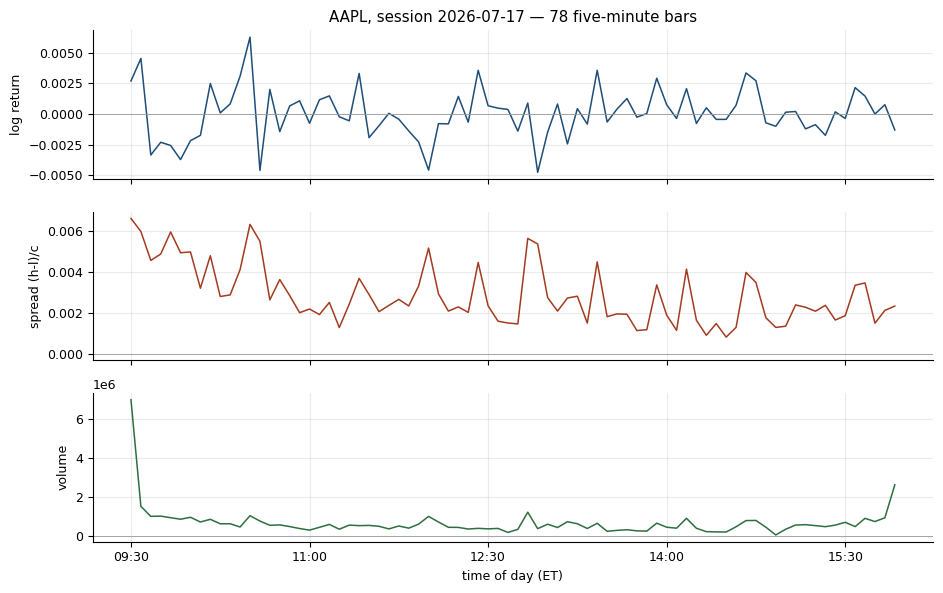

day-image index 10952: AAPL on 2026-07-17
  realised vol over the session : 0.2038% per 5-min bar
  volume at the open / at the close / midday median : 6,984,524 / 2,619,830 / 435,384


In [4]:
"""What one real trading day looks like in all three channels."""
pick_ticker = "AAPL" if "AAPL" in set(tickers) else tickers[0]
mid = len(sessions) // 2
(idx,) = np.where((day.tickers == pick_ticker) & (day.sessions == sessions[mid]))
i0 = int(idx[0])
example_series = day.series[i0]                       # (3, 78)

clock = np.arange(BARS_PER_DAY) * 5 / 60 + 9.5        # decimal hours, 09:30 -> 15:55
ticks = [9.5, 11.0, 12.5, 14.0, 15.5]
tick_labels = ["09:30", "11:00", "12:30", "14:00", "15:30"]

fig, axes = plt.subplots(3, 1, figsize=(9.5, 6.0), sharex=True)
for ax, ch, name, color in zip(axes, example_series, CH_NAMES, CH_COLORS):
    ax.plot(clock, ch, color=color, lw=1.1)
    ax.set_ylabel(name)
    ax.axhline(0, color="0.6", lw=0.6)
axes[0].set_title(f"{pick_ticker}, session {sessions[mid]} — {BARS_PER_DAY} five-minute bars")
axes[2].set_xticks(ticks); axes[2].set_xticklabels(tick_labels)
axes[2].set_xlabel("time of day (ET)")
fig.tight_layout()
plt.show()

print(f"day-image index {i0}: {pick_ticker} on {sessions[mid]}")
print(f"  realised vol over the session : {example_series[0].std():.4%} per 5-min bar")
print(f"  volume at the open / at the close / midday median : "
      f"{example_series[2][0]:,.0f} / {example_series[2][-1]:,.0f} / "
      f"{np.median(example_series[2][30:48]):,.0f}")

## 3. The power / arsinh transform — and a correction to the paper's formula

Raw 5-minute log returns are violently leptokurtic — the cells below print an excess kurtosis
above 30 for returns and above 2000 for volume.
Handed to a diffusion model unmodified, the MSE loss is dominated by a handful of jump bars
and the network spends its capacity on outliers. The paper therefore compresses each
channel before the wavelet step, with

$$\frac{\bigl(X_t - \mu(X_t)\bigr)^{1/p}}{\sigma(X_t)}, \qquad p = 1.5 \ \text{for returns}, \quad p = 1 \ \text{for volume after an } \operatorname{arsinh}.$$

**Read that expression literally and it does not exist on half of our data.** Roughly half
of all log returns are negative, and $(-0.003)^{1/1.5}$ is not a real number. The next cell
demonstrates that rather than asserting it.

The intent is obviously a monotone, variance-stabilising compression of the tails, so we
implement the sign-preserving form. This is flagged here, at the cell where it happens,
because `CLAUDE.md` requires it be visible at the point of use rather than buried in a
deviations table at the bottom of a README.

In [5]:
"""The transform, with the correction stated at the definition.

Mirrors src/diffmodel/transform.py. The fitted per-channel wrapper (ChannelTransform /
DayTransform) is imported rather than re-typed -- it is bookkeeping around these three
functions, and the functions are what the correction is about.
"""

# ===========================================================================
# DEVIATION FROM THE PAPER, FLAGGED AT THE POINT OF USE
#
#     paper:   (X - mu)^(1/p) / sigma          <- undefined for X < mu
#     here:    sign(X - mu) * |X - mu|^(1/p) / sigma
#
# The two agree exactly wherever the paper's form is defined. The signed form is
# additionally odd, monotone on the whole real line, and exactly invertible, which
# the paper's form is not. We read this as repairing an omission rather than
# changing the method -- but it IS a change to the formula as printed, so it is
# stated here and not in a footnote.
# ===========================================================================

def signed_power(x: np.ndarray, p: float) -> np.ndarray:
    """sign(x) * |x|^(1/p). Compresses tails, keeps ordering AND keeps the sign."""
    return np.sign(x) * np.abs(x) ** (1.0 / p)


def signed_power_inv(y: np.ndarray, p: float) -> np.ndarray:
    """Exact inverse: sign(y) * |y|^p."""
    return np.sign(y) * np.abs(y) ** p


def arsinh(x: np.ndarray) -> np.ndarray:
    """log(x + sqrt(x^2 + 1)), used on volume.

    Preferred over log1p because a 5-minute bar can legitimately print zero volume,
    and arsinh is defined at (and through) zero. It behaves like log for large x, so
    it flattens volume's enormous right tail without a special case at the origin.
    """
    return np.arcsinh(x)


# --- 1. the paper's formula, evaluated on real negative returns ---
neg = day.series[:, 0][day.series[:, 0] < 0][:5]
with np.errstate(invalid="ignore"):
    literal = neg ** (1.0 / 1.5)
print("five real log returns          :", np.array2string(neg, precision=6))
print("paper's (X)^(1/1.5), literally :", np.array2string(literal, precision=6))
print("  -> ", f"{np.isnan(literal).mean():.0%} of them are NaN. "
      f"{(day.series[:, 0] < 0).mean():.1%} of ALL log returns in the fixture are negative.")

# --- 2. the sign-preserving form, and its exact inverse ---
back = signed_power_inv(signed_power(neg, 1.5), 1.5)
print(f"\nsign-preserving round-trip     : max |x - inv(fwd(x))| = {np.abs(back - neg).max():.3e}")

# --- 3. faithful-mirror check against the tested copy in src/ ---
probe = fork("nb-transform-probe").normal(size=4096) * 0.01
for f_here, f_src, args in [
    (signed_power, src_transform.signed_power, (1.5,)),
    (signed_power_inv, src_transform.signed_power_inv, (1.5,)),
    (arsinh, src_transform.arsinh, ()),
]:
    assert np.array_equal(f_here(probe, *args), f_src(probe, *args)), f_here.__name__
print("inline == src/diffmodel/transform.py  (bit-identical on 4096 probes)")

five real log returns          : [-0.010545 -0.005957 -0.007481 -0.001448 -0.001597]
paper's (X)^(1/1.5), literally : [nan nan nan nan nan]
  ->  100% of them are NaN. 49.2% of ALL log returns in the fixture are negative.

sign-preserving round-trip     : max |x - inv(fwd(x))| = 3.469e-18
inline == src/diffmodel/transform.py  (bit-identical on 4096 probes)


train (512, 3, 78)  (57 sessions)
val   (128, 3, 78)  (3 sessions, 2026-08-25 -> 2026-08-27)

winsorised fraction at 10 sigma (reported, not hidden):
  returns  0.003%
  spread   0.080%
  volume   0.000%

after transform, per channel:
  log return       mean -0.0005  std 0.9999  kurtosis     2.69  (raw kurtosis    37.37)
  spread (h-l)/c   mean -0.0032  std 0.9505  kurtosis    24.32  (raw kurtosis    80.31)
  volume           mean -0.0000  std 1.0000  kurtosis     0.65  (raw kurtosis  2249.14)


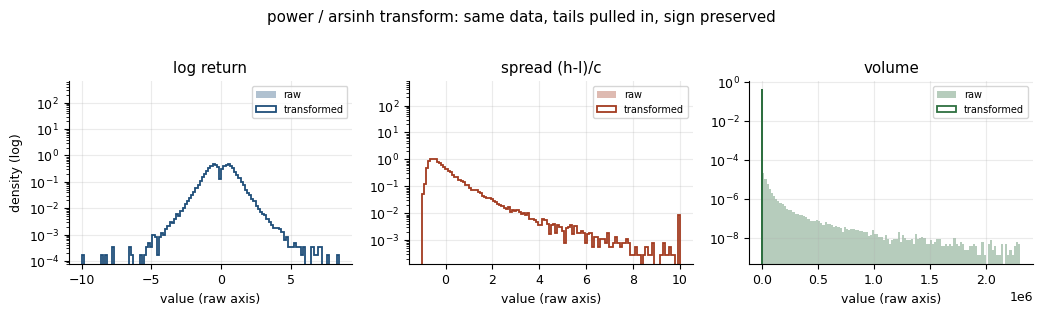

In [6]:
"""Fit the transform on the TRAINING split only, and look at what it does.

Mirrors pipeline.prepare(): split by DATE (never randomly -- a random split would put the
same trading day's AAPL in train and its MSFT in validation, and those two share a
market-wide volatility shock, so validation would be contaminated by construction), then
subsample only the training side under SMOKE so the held-out comparison stays whole.
"""
train_meta, val_meta = day.split_by_date(cfg.val_sessions)
if cfg.max_images is not None:
    train_meta = train_meta.take(cfg.max_images, rng=fork("smoke-subsample"))
    val_meta = val_meta.take(max(32, cfg.max_images // 4), rng=fork("smoke-subsample-val"))

day_transform = DayTransform.fit(
    train_meta.series,
    return_power=cfg.return_power,      # 1.5
    spread_power=cfg.spread_power,      # 1.0
    volume_power=cfg.volume_power,      # 1.0, applied after arsinh
    winsor_sigma=cfg.winsor_sigma,      # 10
)
normed_train = day_transform.forward(train_meta.series)

print(f"train {train_meta.series.shape}  ({np.unique(train_meta.sessions).size} sessions)")
print(f"val   {val_meta.series.shape}  ({np.unique(val_meta.sessions).size} sessions, "
      f"{val_meta.sessions.min()} -> {val_meta.sessions.max()})")
print("\nwinsorised fraction at 10 sigma (reported, not hidden):")
for k, v in day_transform.clipped_report(train_meta.series).items():
    print(f"  {k:8s} {v:.3%}")
print("\nafter transform, per channel:")
for i, name in enumerate(CH_NAMES):
    print(f"  {name:16s} mean {normed_train[:, i].mean():+.4f}  std {normed_train[:, i].std():.4f}  "
          f"kurtosis {ev.excess_kurtosis(normed_train[:, i]):8.2f}  "
          f"(raw kurtosis {ev.excess_kurtosis(train_meta.series[:, i]):8.2f})")

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0))
for ax, i, name, color in zip(axes, range(3), CH_NAMES, CH_COLORS):
    raw = train_meta.series[:, i].ravel()
    lo, hi = np.percentile(raw, [0.2, 99.8])
    ax.hist(raw, bins=120, range=(lo, hi), color=color, alpha=0.35, density=True, label="raw")
    ax.hist(normed_train[:, i].ravel(), bins=120, color=color, histtype="step", lw=1.3,
            density=True, label="transformed")
    ax.set_title(name); ax.set_yscale("log"); ax.set_xlabel("value (raw axis)")
    ax.legend(fontsize=7)
axes[0].set_ylabel("density (log)")
fig.suptitle("power / arsinh transform: same data, tails pulled in, sign preserved", y=1.03)
fig.tight_layout()
plt.show()

## 4. The Haar MODWT, written out

### Why the transform must be undecimated

The paper describes packing *"the $k$-th order coefficients into the $k$-th row of pixels"*.
A textbook **decimated** DWT cannot do that, and the reason is pure counting: it discards
every second coefficient at every level, so on a length-128 signal level 1 keeps 64
coefficients, level 2 keeps 32, level 3 keeps 16, down to 1 at level 7.

Those are seven rows of *different lengths*. They do not tile a rectangle. There is no image
whose $k$-th row is "the level-$k$ coefficients", so the paper's central construction is not
merely awkward under a decimated transform — it is undefined.

The **maximal-overlap** DWT (MODWT; also called undecimated, stationary, or à trous) simply
does not decimate. It keeps all $N$ coefficients at every level, so $8 \times 128$ is a
genuine rectangle. It buys two further things this application needs:

- **Shift equivariance.** Delay the session by one bar and every coefficient slides one
  column along its row. Under a decimated DWT the same shift *reshuffles* which coefficients
  survive at each level, so a volatility burst at 10:05 and the identical burst at 10:10
  would produce structurally different images. A convolutional network would have to learn
  both separately.
- **An exactly additive decomposition.** $\sum_j W_j + V_J = x$, pointwise. Every row is a
  band of the original signal in the original units, which is what makes the picture in §5
  readable as a signal rather than as a code.

The cost is redundancy: $8 \times 128 = 1024$ numbers describing 128. That is the trade, and
it is the trade the method is built on — the DDPM gets a representation in which *scale is
an axis it can convolve and attend across*, rather than something entangled inside a flat
sequence.

### The filters

Haar filters rescaled for the MODWT are $\tilde g = [\tfrac12, \tfrac12]$ and
$\tilde h = [\tfrac12, -\tfrac12]$. At level $j$ they are dilated by $s = 2^{j-1}$ (zeros
inserted between taps) and convolved circularly. With $V_0 = x$:

$$W_j[t] = \tfrac12\bigl(V_{j-1}[t] - V_{j-1}[t-s]\bigr), \qquad
  V_j[t] = \tfrac12\bigl(V_{j-1}[t] + V_{j-1}[t-s]\bigr).$$

### The inverse

Adding and subtracting those two lines gives two separate expressions that each recover
$V_{j-1}$:

$$V_j[t] + W_j[t] = V_{j-1}[t], \qquad V_j[t+s] - W_j[t+s] = V_{j-1}[t].$$

The first is immediate; the second follows because $V_j[t+s] - W_j[t+s] = V_{j-1}[t+s-s] = V_{j-1}[t]$.
Either alone inverts the transform. Averaging them is what the code below does, and it is
the numerically symmetric choice — it treats the two circular directions identically instead
of accumulating drift in one of them.

In [7]:
"""Mirror-expansion and the Haar MODWT, forward and inverse.

Mirrors src/diffmodel/wavelet.py. Everything operates on the LAST axis and broadcasts over
any leading axes, so one implementation serves a single series, a (3, 128) day, and a
(batch, 3, 128) minibatch without a reshape anywhere.
"""

def pad_to_pow2(x: np.ndarray, target: int, mode: str = "mirror") -> np.ndarray:
    """Extend the last axis from n to `target`. The paper calls this mirror expansion.

    `mirror` reflects without repeating the edge sample: [a b c d] -> [a b c d c b]. That
    keeps the extension statistically like the signal, which matters because the circular
    convolution below wraps the tail of the padded signal onto its head. `zero` and
    `periodic` exist so the choice is ablatable -- the model WILL learn whatever symmetry
    the padding creates, and that is a known artifact of the approach, not a bug.
    """
    n = x.shape[-1]
    if n == target:
        return x.copy()
    if n > target:
        raise ValueError(f"signal length {n} exceeds target {target}")
    pad = target - n
    widths = [(0, 0)] * (x.ndim - 1) + [(0, pad)]
    if mode == "mirror":
        if pad >= n:
            raise ValueError(f"mirror padding needs pad ({pad}) < n ({n})")
        return np.pad(x, widths, mode="reflect")
    if mode == "zero":
        return np.pad(x, widths, mode="constant", constant_values=0.0)
    if mode == "periodic":
        return np.pad(x, widths, mode="wrap")
    raise ValueError(f"unknown pad mode {mode!r}")


def unpad(x: np.ndarray, n: int) -> np.ndarray:
    """Inverse of `pad_to_pow2`: keep the first n samples, drop the mirrored extension."""
    return x[..., :n]


def modwt(x: np.ndarray, levels: int) -> np.ndarray:
    """Haar MODWT -> (..., levels + 1, N) coefficient planes, finest detail first.

    Rows 0..levels-1 are the details W_1..W_J; row `levels` is the final smooth V_J.
    Finest-first means row 0 is 5-minute-scale variation and row 6 is roughly
    half-session scale, so the row index reads as an octave.
    """
    if levels < 1:
        raise ValueError("levels must be >= 1")
    n = x.shape[-1]
    if 2 ** levels > n:
        raise ValueError(f"levels={levels} needs N >= {2 ** levels}, got {n}")

    v = x.astype(np.float64, copy=True)
    planes = []
    for j in range(1, levels + 1):
        s = 1 << (j - 1)                     # dilation 2^(j-1)
        v_lag = np.roll(v, s, axis=-1)       # V[t - s], circular
        planes.append(0.5 * (v - v_lag))     # W_j
        v = 0.5 * (v + v_lag)                # V_j
    planes.append(v)                          # V_J
    return np.stack(planes, axis=-2)


def imodwt(planes: np.ndarray) -> np.ndarray:
    """Exact inverse of `modwt`. (..., levels + 1, N) -> (..., N)."""
    levels = planes.shape[-2] - 1
    v = planes[..., levels, :].astype(np.float64, copy=True)
    for j in range(levels, 0, -1):
        s = 1 << (j - 1)
        w = planes[..., j - 1, :]
        w_lead = np.roll(w, -s, axis=-1)     # W[t + s]
        v_lead = np.roll(v, -s, axis=-1)     # V[t + s]
        # the average of the two identities derived above
        v = 0.5 * (v + w) + 0.5 * (v_lead - w_lead)
    return v


def series_to_image(series, levels, target, pad_mode="mirror"):
    """(..., C, n) time series -> (..., C, levels + 1, target) coefficient image.

    Each channel is transformed INDEPENDENTLY. Nothing here couples returns to spread to
    volume -- the DDPM is what learns their joint structure, exactly as in the paper. That
    is precisely why cross-channel correlation is a fact the model can get WRONG, and so is
    worth scoring rather than assuming.
    """
    return modwt(pad_to_pow2(series, target, mode=pad_mode), levels)


def image_to_series(image, n):
    """(..., C, levels + 1, target) -> (..., C, n). Inverse of `series_to_image`."""
    return unpad(imodwt(image), n)

In [8]:
"""The round-trip assertion, EXECUTED, and the counting argument, EVALUATED.

CLAUDE.md non-negotiable #2: every transform is exactly invertible and there is a check
that proves it, at max |x - inv(fwd(x))| < 1e-10.
"""
TOL = 1e-10
rng = fork("nb-wavelet-check")

# --- 1. round trip on REAL data, the whole training split at once ---
real_img = series_to_image(normed_train, N_LEVELS, PADDED_LEN)
real_back = image_to_series(real_img, BARS_PER_DAY)
err_real = np.abs(real_back - normed_train).max()

# --- 2. round trip on white noise, which has energy at every scale ---
noise = rng.normal(size=(8, 3, BARS_PER_DAY))
err_noise = np.abs(image_to_series(series_to_image(noise, N_LEVELS, PADDED_LEN), BARS_PER_DAY) - noise).max()

# --- 3. every level count from 1 to 7, on the padded signal ---
padded_noise = pad_to_pow2(noise, PADDED_LEN)
errs_by_level = {J: float(np.abs(imodwt(modwt(padded_noise, J)) - padded_noise).max())
                 for J in range(1, N_LEVELS + 1)}

print(f"round trip, real training split {normed_train.shape}")
print(f"   max |x - inv(fwd(x))| = {err_real:.3e}   {'PASS' if err_real < TOL else 'FAIL'}  (tol {TOL:g})")
print(f"round trip, white noise")
print(f"   max |x - inv(fwd(x))| = {err_noise:.3e}   {'PASS' if err_noise < TOL else 'FAIL'}")
print(f"round trip, levels 1..{N_LEVELS}: max error {max(errs_by_level.values()):.3e} "
      f"(worst at J={max(errs_by_level, key=errs_by_level.get)})")
assert err_real < TOL and err_noise < TOL and max(errs_by_level.values()) < TOL

# --- 4. the additive decomposition: rows sum to the signal, pointwise ---
add_err = np.abs(real_img.sum(axis=-2) - pad_to_pow2(normed_train, PADDED_LEN)).max()
print(f"\nadditive decomposition  max |sum_j W_j + V_J - x| = {add_err:.3e}")
assert add_err < TOL

# --- 5. shift equivariance: the property a decimated DWT lacks ---
shift = 7
eq_err = np.abs(modwt(np.roll(padded_noise, shift, axis=-1), N_LEVELS)
                - np.roll(modwt(padded_noise, N_LEVELS), shift, axis=-1)).max()
print(f"shift equivariance      max |MODWT(roll(x,{shift})) - roll(MODWT(x),{shift})| = {eq_err:.3e}")
assert eq_err < TOL

# --- 6. the counting argument, made concrete ---
dec = [PADDED_LEN >> j for j in range(1, N_LEVELS + 1)]
print(f"\ndecimated DWT on N={PADDED_LEN}: coefficients per level = {dec} (+1 smooth)")
print(f"   -> {sum(dec) + 1} numbers in {N_LEVELS + 1} rows of DIFFERENT lengths. Not a rectangle.")
print(f"MODWT       on N={PADDED_LEN}: coefficients per level = {[PADDED_LEN] * N_LEVELS} (+{PADDED_LEN} smooth)")
print(f"   -> {(N_LEVELS + 1) * PADDED_LEN} numbers in a {N_LEVELS + 1} x {PADDED_LEN} rectangle. "
      f"{(N_LEVELS + 1) * PADDED_LEN / PADDED_LEN:.0f}x redundant, and that redundancy is the point.")

# --- 7. faithful-mirror check against the tested copy in src/ ---
# Every public name in this cell's block, and every branch of the one that has branches:
# `mirror` is what the pipeline uses, but `zero` and `periodic` exist so the padding choice
# is ablatable, and an unasserted branch is exactly where a divergence would hide.
assert np.array_equal(modwt(padded_noise, N_LEVELS), src_wavelet.modwt(padded_noise, N_LEVELS))
assert np.array_equal(imodwt(real_img), src_wavelet.imodwt(real_img))
for pad_mode in ("mirror", "zero", "periodic"):
    assert np.array_equal(pad_to_pow2(noise, PADDED_LEN, pad_mode),
                          src_wavelet.pad_to_pow2(noise, PADDED_LEN, pad_mode))
assert np.array_equal(unpad(padded_noise, BARS_PER_DAY),
                      src_wavelet.unpad(padded_noise, BARS_PER_DAY))
assert np.array_equal(series_to_image(normed_train, N_LEVELS, PADDED_LEN),
                      src_wavelet.series_to_image(normed_train, N_LEVELS, PADDED_LEN))
assert np.array_equal(image_to_series(real_img, BARS_PER_DAY),
                      src_wavelet.image_to_series(real_img, BARS_PER_DAY))
print("\ninline == src/diffmodel/wavelet.py  (bit-identical: modwt, imodwt, pad_to_pow2 at all")
print("three pad modes, unpad, series_to_image, image_to_series)")

round trip, real training split (512, 3, 78)
   max |x - inv(fwd(x))| = 1.776e-15   PASS  (tol 1e-10)
round trip, white noise
   max |x - inv(fwd(x))| = 4.441e-16   PASS
round trip, levels 1..7: max error 4.441e-16 (worst at J=1)

additive decomposition  max |sum_j W_j + V_J - x| = 3.553e-15
shift equivariance      max |MODWT(roll(x,7)) - roll(MODWT(x),7)| = 0.000e+00

decimated DWT on N=128: coefficients per level = [64, 32, 16, 8, 4, 2, 1] (+1 smooth)
   -> 128 numbers in 8 rows of DIFFERENT lengths. Not a rectangle.
MODWT       on N=128: coefficients per level = [128, 128, 128, 128, 128, 128, 128] (+128 smooth)
   -> 1024 numbers in a 8 x 128 rectangle. 8x redundant, and that redundancy is the point.

inline == src/diffmodel/wavelet.py  (bit-identical: modwt, imodwt, pad_to_pow2 at all
three pad modes, unpad, series_to_image, image_to_series)


## 5. The coefficient-plane image

This is the picture the whole paper turns on. One trading session becomes an $8 \times 128$
grid per channel: **row = octave, column = time, value = wavelet coefficient**. Stack the
three channels and it is literally an RGB image, which is why an image DDPM can be pointed
at it without modification.

Two things to look for:

1. **The finest rows are noisy and the coarsest are smooth.** Row 0 ($W_1$) is 5-minute
   variation; row 6 ($W_7$) is roughly half-session variation; row 7 ($V_7$) is the residual
   level. Volatility clustering appears as *vertical* coherence — a burst that lights up
   several rows in the same column.
2. **Columns 78–127 are the mirror extension**, marked below. They are not data. They exist
   so the length is $2^7$, they are generated by the model like everything else, and
   `image_to_series` throws them away on the way back.

A third thing, once you have looked at the plot: the $V_7$ row of the **volume** channel reads
as one flat saturated band. That is not an artifact. $V_7$ is the residual smooth level, so it
carries the session's overall magnitude — and volume is dominated by its own level in a way
returns are not. The energy table two cells below puts a number on that, and it is the clearest
single reason the three channels are not interchangeable to the model.

One last normalisation before the model sees this: each (channel, level) pair is centred and
scaled by its own training statistics and then divided by 3, so the whole tensor lands mostly
in $[-1, 1]$. Detail planes at different octaves have wildly different variances and a DDPM
wants its input on one scale. It is a fixed affine map fitted **once on the training split**
— exactly invertible, and it leaks nothing from validation.

In [9]:
"""Assemble the Codec by hand, then check it against pipeline.prepare().

The images below are built by `encode_inline`, which calls the INLINE wavelet from section 4
-- deliberately NOT `Codec.encode`, which resolves `series_to_image` from `diffmodel.wavelet`
and would turn the assertion into src compared against itself. So what is asserted here is
the whole notebook-side chain: this notebook's date split, its own fitted `DayTransform`, its
own level statistics and its own MODWT produce bit-identical images to `pipeline.prepare()`.
That is what makes this notebook's claim -- "the inline code is what actually trained the
model" -- checkable rather than rhetorical.

The `Codec` object is still built and kept, because section 10 decodes through it: the
scorecard's decode path and the notebook's must be the same object, not two copies.
"""
# Level statistics must be fitted on TRAIN images only, so build those first.
raw_train_img = series_to_image(day_transform.forward(train_meta.series), N_LEVELS, PADDED_LEN)
level_stats = fit_level_stats(raw_train_img)
codec = Codec(day_transform, level_stats, pad_mode="mirror")


def encode_inline(series):
    """`Codec.encode`, spelled out against the inline MODWT rather than the src one."""
    normed = day_transform.forward(series)
    img = series_to_image(normed, N_LEVELS, PADDED_LEN, pad_mode=codec.pad_mode)
    return apply_level_stats(img, level_stats, codec.image_scale)


train_images = encode_inline(train_meta.series).astype(np.float32)
val_images = encode_inline(val_meta.series).astype(np.float32)

# The canonical path, for comparison.
prep = prepare(cfg)
assert np.array_equal(train_images, prep.train_images), "notebook and pipeline.prepare disagree"
assert np.array_equal(val_images, prep.val_images)
assert np.array_equal(train_images, codec.encode(train_meta.series).astype(np.float32))
print("\ninline pipeline == pipeline.prepare()  (bit-identical images, encoded through the")
print("inline MODWT: split, transform fit, level-stat fit and wavelet all notebook-side)")

print(f"\nencode/decode round trip on held-out data, in units of each channel's own std:")
for k, v in codec.roundtrip_report(val_meta.series).items():
    print(f"  {k:8s} {v:.3e}")
print("  (relative error would be the wrong metric here: the inverses are sign(z)|z|^1.5 and")
print("   sinh, both of which blow relative error up without bound near zero. The spread")
print("   channel is large because 10-sigma winsorisation genuinely does not invert -- that")
print("   is what winsorisation IS, and clipped_report above says how much of it there is.)")

winsorised fraction at 10 sigma: returns=0.00%, spread=0.08%, volume=0.00%
train (512, 3, 8, 128)  val (128, 3, 8, 128)
  train sessions 57, val sessions 3
  image range [-6.35, 6.35], std 0.333

inline pipeline == pipeline.prepare()  (bit-identical images, encoded through the
inline MODWT: split, transform fit, level-stat fit and wavelet all notebook-side)

encode/decode round trip on held-out data, in units of each channel's own std:
  returns  4.152e-07
  spread   2.010e+01
  volume   2.706e-06
  (relative error would be the wrong metric here: the inverses are sign(z)|z|^1.5 and
   sinh, both of which blow relative error up without bound near zero. The spread
   channel is large because 10-sigma winsorisation genuinely does not invert -- that
   is what winsorisation IS, and clipped_report above says how much of it there is.)


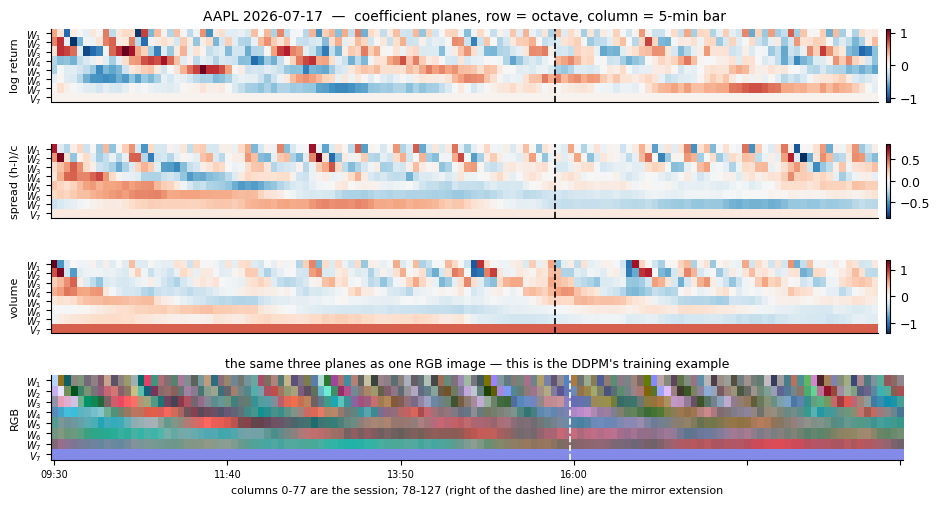

image tensor (3, 8, 128), range [-1.15, 1.37]
training set (512, 3, 8, 128), std 0.333


In [10]:
"""The picture: one session as 3 x 8 x 128 coefficient planes."""
ex = codec.encode(example_series[None])[0]        # (3, 8, 128)
row_labels = [f"$W_{j}$" for j in range(1, N_LEVELS + 1)] + [f"$V_{N_LEVELS}$"]
row_names = [f"W{j}" for j in range(1, N_LEVELS + 1)] + [f"V{N_LEVELS}"]   # plain, for tables

fig = plt.figure(figsize=(11.0, 5.6))
gs = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 1.15], hspace=0.55)

for i, (name, cmap) in enumerate(zip(CH_NAMES, ("RdBu_r", "RdBu_r", "RdBu_r"))):
    ax = fig.add_subplot(gs[i])
    lim = np.abs(ex[i]).max()
    im = ax.imshow(ex[i], aspect="auto", cmap=cmap, vmin=-lim, vmax=lim, interpolation="nearest")
    ax.axvline(BARS_PER_DAY - 0.5, color="k", lw=1.2, ls="--")
    ax.set_yticks(range(IMAGE_ROWS)); ax.set_yticklabels(row_labels, fontsize=7)
    ax.set_ylabel(name, fontsize=8)
    ax.set_xticks([]); ax.grid(False)
    fig.colorbar(im, ax=ax, pad=0.01, fraction=0.02)
    if i == 0:
        ax.set_title(f"{pick_ticker} {sessions[mid]}  —  coefficient planes, row = octave, column = 5-min bar",
                     fontsize=10)


# The three channels together, as the literal RGB image the DDPM is trained on.
ax = fig.add_subplot(gs[3])
rgb = np.clip((np.transpose(ex, (1, 2, 0)) + 1.0) / 2.0, 0, 1)
ax.imshow(rgb, aspect="auto", interpolation="nearest")
ax.axvline(BARS_PER_DAY - 0.5, color="w", lw=1.2, ls="--")
ax.set_yticks(range(IMAGE_ROWS)); ax.set_yticklabels(row_labels, fontsize=7)
ax.set_ylabel("RGB", fontsize=8); ax.grid(False)
ax.set_xticks([0, 26, 52, 78, 104, 127])
ax.set_xticklabels(["09:30", "11:40", "13:50", "16:00", "", ""], fontsize=7)
ax.set_xlabel("columns 0-77 are the session; 78-127 (right of the dashed line) are the "
              "mirror extension", fontsize=8)
ax.set_title("the same three planes as one RGB image — this is the DDPM's training example",
             fontsize=9)
plt.show()

print(f"image tensor {ex.shape}, range [{ex.min():.2f}, {ex.max():.2f}]")
print(f"training set {train_images.shape}, std {train_images.std():.3f}")

In [11]:
"""Which octave holds each channel's energy. The three channels are not interchangeable."""
energy = raw_train_img.var(axis=(0, 3))                   # (3, 8), before per-level rescaling
share = energy / energy.sum(axis=1, keepdims=True)

print(f"{'share of variance':<18s}" + "".join(f"{r:>8s}" for r in row_names))
for i, name in enumerate(CH_NAMES):
    print(f"{name:<18s}" + "".join(f"{100 * v:7.1f}%" for v in share[i]))
print()
print("log returns put half their variance in W1 -- 5-minute returns are close to white noise,")
print("so there is very little for the coarse octaves to hold. Volume is the opposite: three")
print("quarters of its variance sits in V7, the session's own level. Spread is in between.")
print("Per-(channel, level) standardisation exists precisely because these differ by ~50x, and")
print("a DDPM wants its input on one scale.")

share of variance       W1      W2      W3      W4      W5      W6      W7      V7
log return           51.0%   24.2%   12.0%    6.4%    3.2%    1.5%    0.8%    1.0%
spread (h-l)/c       19.4%   12.8%    9.9%    9.4%    9.7%    8.7%    4.5%   25.5%
volume                5.6%    3.6%    2.9%    3.1%    3.6%    2.9%    0.8%   77.3%

log returns put half their variance in W1 -- 5-minute returns are close to white noise,
so there is very little for the coarse octaves to hold. Volume is the opposite: three
quarters of its variance sits in V7, the session's own level. Spread is in between.
Per-(channel, level) standardisation exists precisely because these differ by ~50x, and
a DDPM wants its input on one scale.


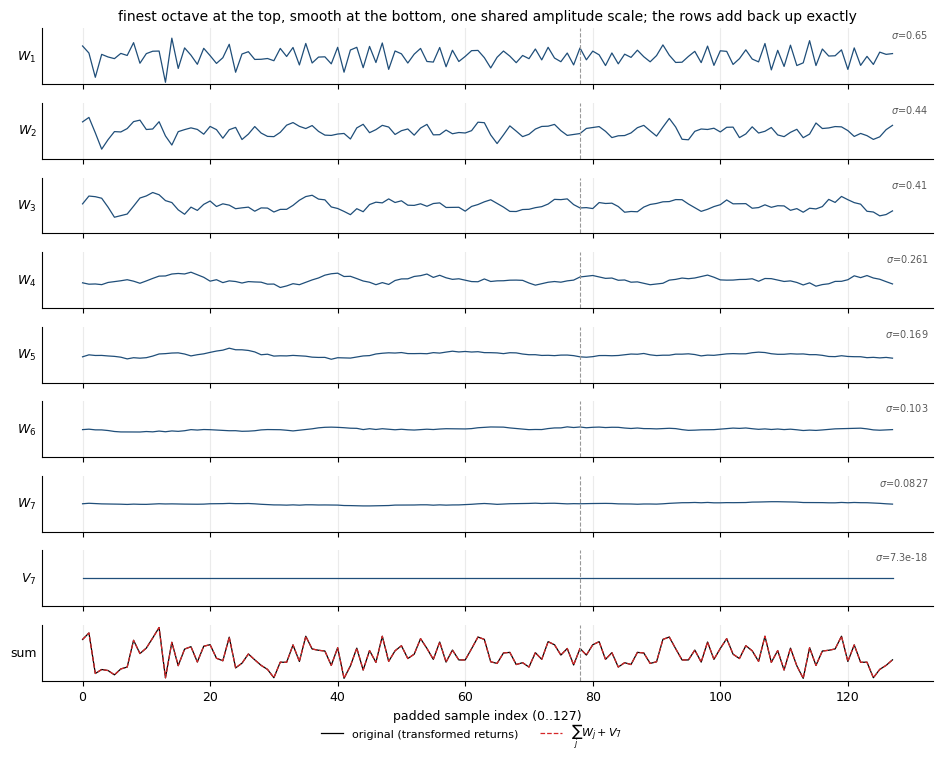

max |sum of rows - original| = 4.441e-16


In [12]:
"""The additive decomposition, drawn: the eight rows of the return channel sum to the signal."""
sig = pad_to_pow2(day_transform.forward(example_series[None])[0, 0], PADDED_LEN)
pl = modwt(sig, N_LEVELS)

# One SHARED y-scale across the eight plane rows. Autoscaling each row independently would
# make V7 look as busy as W1, which is exactly backwards: the point is the amplitude hierarchy.
lim = float(np.abs(pl).max()) * 1.08

fig, axes = plt.subplots(IMAGE_ROWS + 1, 1, figsize=(9.5, 7.4), sharex=True)
for j in range(IMAGE_ROWS):
    axes[j].plot(pl[j], color=CH_COLORS[0], lw=0.9)
    axes[j].set_ylabel(row_labels[j], rotation=0, ha="right", va="center", fontsize=9)
    axes[j].set_yticks([]); axes[j].set_ylim(-lim, lim)
    axes[j].axvline(BARS_PER_DAY, color="0.6", lw=0.8, ls="--")
    axes[j].text(0.995, 0.82, f"$\\sigma$={pl[j].std():.3g}", transform=axes[j].transAxes,
                 ha="right", fontsize=7, color="0.35")
axes[-1].plot(sig, color="k", lw=0.9, label="original (transformed returns)")
axes[-1].plot(pl.sum(axis=0), color="#d62728", lw=0.9, ls="--", label=r"$\sum_j W_j + V_7$")
axes[-1].set_ylabel("sum", rotation=0, ha="right", va="center", fontsize=9)
axes[-1].set_yticks([]); axes[-1].axvline(BARS_PER_DAY, color="0.6", lw=0.8, ls="--")
axes[-1].set_xlabel("padded sample index (0..127)")
axes[0].set_title("finest octave at the top, smooth at the bottom, one shared amplitude scale; "
                  "the rows add back up exactly", fontsize=10)
fig.legend(*axes[-1].get_legend_handles_labels(), loc="lower center", ncol=2, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.035))
fig.tight_layout()
plt.show()
print(f"max |sum of rows - original| = {np.abs(pl.sum(axis=0) - sig).max():.3e}")

## 6. Forward diffusion: $q(x_t \mid x_0)$

Corrupt the image with Gaussian noise over $T$ steps under a fixed variance schedule
$\beta_1 \dots \beta_T$:

$$q(x_t \mid x_{t-1}) = \mathcal N\!\left(\sqrt{1-\beta_t}\, x_{t-1},\ \beta_t I\right).$$

Write $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s\le t}\alpha_s$. Because Gaussians
compose, the whole chain collapses into one step:

$$q(x_t \mid x_0) = \mathcal N\!\left(\sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t) I\right)
\qquad\Longrightarrow\qquad
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon, \quad \epsilon \sim \mathcal N(0, I).$$

That identity is why training is cheap: draw a random $t$ per example and jump straight
there, instead of simulating $t$ steps. It is also where the bugs live — almost every silent
DDPM failure is an off-by-one in $\bar\alpha$ rather than a mistake in the network — so the
cell below checks the closed form against an explicitly iterated chain.

**A note on the schedule, which is not a style preference.** The linear schedule's endpoints
$(10^{-4}, 0.02)$ are tuned for $T = 1000$. Shrink $T$ without moving them and
$\bar\alpha_T$ never reaches zero, so the forward chain never reaches pure noise and the
sampler would start from a distribution the model was never trained on. `SMOKE` therefore
uses cosine, which defines $\bar\alpha$ directly and reaches $\approx 0$ at any $T$. The next
cell prints the numbers instead of asking you to trust that.

In [13]:
"""The schedules and q(x_t | x_0), written out.

Mirrors src/diffmodel/ddpm.py. Buffers are accumulated in float64 and cast to float32 only
at the end: alphabar is a cumulative product over up to 1000 terms and accumulates real
error in float32, which surfaces as a sampler that never quite converges.
"""
from dataclasses import dataclass


def linear_beta_schedule(timesteps, start=1e-4, end=0.02):
    """The original DDPM schedule (Ho et al. 2020), and the one the paper follows."""
    return torch.linspace(start, end, timesteps, dtype=torch.float64)


def cosine_beta_schedule(timesteps, s=0.008):
    """Nichol & Dhariwal (2021): defines alphabar directly, so it reaches ~0 at any T."""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float64)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    # Upper clip 0.999, the value Nichol & Dhariwal give ("no larger than 0.999 to prevent
    # singularities at the end of the diffusion process"). It bounds the reverse step's state
    # gain 1/sqrt(alpha_t) at ~31.6; a 0.9999 clip would allow alpha_t = 1e-4, i.e. a 100x
    # gain on the FIRST reverse step at T=50. Section 11 measures what that does.
    return torch.clip(betas, 0.0001, 0.999)


@dataclass
class DiffusionSchedule:
    """Every buffer the forward and reverse processes need, precomputed once."""

    betas: torch.Tensor
    alphas: torch.Tensor
    alphas_cumprod: torch.Tensor
    alphas_cumprod_prev: torch.Tensor
    sqrt_alphas_cumprod: torch.Tensor
    sqrt_one_minus_alphas_cumprod: torch.Tensor
    sqrt_recip_alphas: torch.Tensor
    posterior_variance: torch.Tensor
    # q(x_{t-1} | x_t, x0) mean = coef1 * x0 + coef2 * x_t (Ho et al. eq. 7). Built in
    # float64 like the rest: coef1's denominator (1 - alphabar_t) is ~1e-4 at t=0, so
    # deriving it from the stored float32 alphabar loses digits to cancellation.
    posterior_mean_coef1: torch.Tensor
    posterior_mean_coef2: torch.Tensor

    @classmethod
    def build(cls, timesteps, kind="linear", start=1e-4, end=0.02):
        if kind == "linear":
            betas = linear_beta_schedule(timesteps, start, end)
        elif kind == "cosine":
            betas = cosine_beta_schedule(timesteps)
        else:
            raise ValueError(f"unknown beta schedule {kind!r}")

        alphas = 1.0 - betas
        acp = torch.cumprod(alphas, dim=0)
        acp_prev = torch.cat([torch.ones(1, dtype=torch.float64), acp[:-1]])

        if acp[-1] > 1e-3:
            warnings.warn(
                f"alphabar_T = {acp[-1]:.4g} is not ~0 with T={timesteps} and the '{kind}' "
                f"schedule: the forward chain does not reach pure noise, so samples will "
                f"start off-distribution.", stacklevel=2)

        f32 = lambda t: t.to(torch.float32)  # noqa: E731
        return cls(
            betas=f32(betas), alphas=f32(alphas), alphas_cumprod=f32(acp),
            alphas_cumprod_prev=f32(acp_prev),
            sqrt_alphas_cumprod=f32(torch.sqrt(acp)),
            sqrt_one_minus_alphas_cumprod=f32(torch.sqrt(1.0 - acp)),
            sqrt_recip_alphas=f32(torch.sqrt(1.0 / alphas)),
            # beta~_t. Element 0 is 0 by construction (alphabar_{-1} = 1), which is
            # correct: the final reverse step is deterministic.
            posterior_variance=f32(betas * (1.0 - acp_prev) / (1.0 - acp)),
            posterior_mean_coef1=f32(betas * torch.sqrt(acp_prev) / (1.0 - acp)),
            posterior_mean_coef2=f32((1.0 - acp_prev) * torch.sqrt(alphas) / (1.0 - acp)),
        )

    def to(self, device):
        return DiffusionSchedule(**{k: v.to(device) for k, v in self.__dict__.items()})

    def __len__(self):
        return len(self.betas)


def _gather(buf, t, ndim):
    """Index a per-timestep buffer and reshape it to broadcast over (B, C, H, W)."""
    return buf.gather(0, t).reshape(-1, *([1] * (ndim - 1)))


def q_sample(x0, t, sched, noise=None):
    """Jump straight to noise level t: x_t = sqrt(abar_t) x0 + sqrt(1 - abar_t) eps."""
    if noise is None:
        noise = torch.randn_like(x0)
    a = _gather(sched.sqrt_alphas_cumprod, t, x0.ndim)
    b = _gather(sched.sqrt_one_minus_alphas_cumprod, t, x0.ndim)
    return a * x0 + b * noise, noise

In [14]:
"""Check the schedule, then check the closed form against an explicitly iterated chain."""
sched_cpu = DiffusionSchedule.build(cfg.timesteps, kind=cfg.beta_schedule)

print(f"{'schedule':>18s}  {'alphabar_T':>12s}  {'min alpha_t':>12s}   verdict")
for kind, T in [("linear", cfg.timesteps), ("cosine", cfg.timesteps), ("linear", 1000)]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        s = DiffusionSchedule.build(T, kind=kind)
    ab = float(s.alphas_cumprod[-1])
    verdict = "reaches pure noise" if ab < 1e-3 else "NEVER reaches pure noise"
    star = "  <- this run" if (kind, T) == (cfg.beta_schedule, cfg.timesteps) else ""
    print(f"{kind + ' T=' + str(T):>18s}  {ab:12.3e}  {float(s.alphas.min()):12.4g}   {verdict}{star}")

# The closed form must equal the iterated chain in distribution. Seeded, not global RNG.
g = torch_generator("nb-forward-check")
x0 = torch.from_numpy(train_images[:512]).float()
xt = x0.clone()
for i in range(len(sched_cpu)):
    beta = sched_cpu.betas[i]
    xt = torch.sqrt(1 - beta) * xt + torch.sqrt(beta) * torch.randn(xt.shape, generator=g)

t_last = torch.full((x0.shape[0],), len(sched_cpu) - 1, dtype=torch.long)
closed, _ = q_sample(x0, t_last, sched_cpu, noise=torch.randn(x0.shape, generator=g))
print(f"\niterated chain to t=T   : mean {xt.mean():+.4f}  std {xt.std():.4f}")
print(f"closed form q(x_T | x_0): mean {closed.mean():+.4f}  std {closed.std():.4f}")
print(f"target N(0, I)          : mean {0.0:+.4f}  std {1.0:.4f}")

# --- faithful-mirror check against the tested copy in src/ ---
src_sched = src_ddpm.DiffusionSchedule.build(cfg.timesteps, kind=cfg.beta_schedule)
for k in sched_cpu.__dict__:
    assert torch.equal(getattr(sched_cpu, k), getattr(src_sched, k)), k
qa, _ = q_sample(x0[:4], t_last[:4], sched_cpu, noise=torch.zeros_like(x0[:4]))
qb, _ = src_ddpm.q_sample(x0[:4], t_last[:4], src_sched, noise=torch.zeros_like(x0[:4]))
assert torch.equal(qa, qb)
print("\ninline == src/diffmodel/ddpm.py  (schedule buffers and q_sample bit-identical)")

          schedule    alphabar_T   min alpha_t   verdict
       linear T=50     6.030e-01          0.98   NEVER reaches pure noise
       cosine T=50     9.712e-07         0.001   reaches pure noise  <- this run
     linear T=1000     4.036e-05          0.98   reaches pure noise

iterated chain to t=T   : mean +0.0006  std 1.0005
closed form q(x_T | x_0): mean -0.0001  std 1.0004
target N(0, I)          : mean +0.0000  std 1.0000

inline == src/diffmodel/ddpm.py  (schedule buffers and q_sample bit-identical)


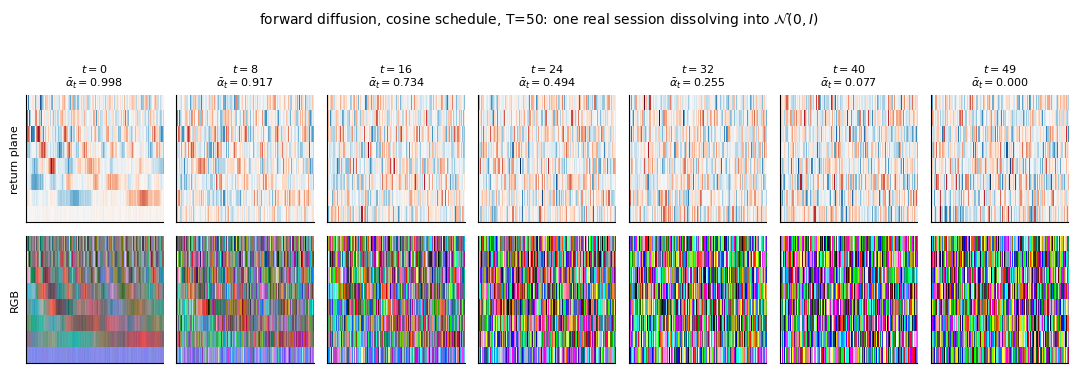

In [15]:
"""One image dissolving into noise. This is the forward process, run on real data."""
show_t = np.unique(np.linspace(0, cfg.timesteps - 1, 7).astype(int))
x0_one = torch.from_numpy(codec.encode(example_series[None])).float()

fig, axes = plt.subplots(2, len(show_t), figsize=(1.55 * len(show_t), 3.6))
for col, ti in enumerate(show_t):
    t = torch.tensor([int(ti)], dtype=torch.long)
    xt_one, _ = q_sample(x0_one, t, sched_cpu, noise=torch.randn(x0_one.shape, generator=g))
    arr = xt_one[0].numpy()
    lim = max(float(np.abs(arr).max()), 1e-9)
    axes[0, col].imshow(arr[0], aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim,
                        interpolation="nearest")
    axes[1, col].imshow(np.clip((np.transpose(arr, (1, 2, 0)) + 1) / 2, 0, 1),
                        aspect="auto", interpolation="nearest")
    abar = float(sched_cpu.alphas_cumprod[int(ti)])
    axes[0, col].set_title(f"$t={ti}$\n$\\bar\\alpha_t={abar:.3f}$", fontsize=8)
    for r in (0, 1):
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([]); axes[r, col].grid(False)
axes[0, 0].set_ylabel("return plane", fontsize=8)
axes[1, 0].set_ylabel("RGB", fontsize=8)
fig.suptitle(f"forward diffusion, {cfg.beta_schedule} schedule, T={cfg.timesteps}: "
             f"one real session dissolving into $\\mathcal{{N}}(0, I)$", y=1.02, fontsize=10)
fig.tight_layout()
plt.show()

## 7. The UNet noise predictor

Standard DDPM architecture (Ho et al. 2020), written from primitives rather than imported
from `diffusers`, because the whole point of this project is that the internals are legible.
A symmetric encoder/decoder with skip connections; residual blocks conditioned on the
diffusion timestep through a sinusoidal embedding; self-attention at the lowest resolution
only. Input and output are both $(B, 3, 8, 128)$ — the network's job is to output an
estimate of the noise, which is the same shape as the image.

Three design choices worth naming, all of which have a financial reason and not just an
imaging one:

- **Attention only at the bottleneck.** There the map is $2 \times 32 = 64$ positions and the
  quadratic cost is irrelevant. Convolutions have a bounded receptive field; attention lets a
  coefficient at 09:35 in the finest octave interact *directly* with one at 15:50 in the
  coarsest, which is how a whole-session volatility regime gets represented coherently rather
  than as a chain of local effects. **`SMOKE` switches it off**
  (`attention_at_bottleneck=False`, and `num_res_blocks=1` rather than 2), so the network
  instantiated below — the one whose parameter count is printed and which produces every
  sample in this file — contains no `AttentionBlock` at all. `FULL` turns both on. This is a
  statement about the *architecture*; whether this particular run exercises it is a separate
  question, and the cell below answers it out loud.
- **Nearest-neighbour upsampling, not `ConvTranspose2d`.** Transposed convolutions produce
  checkerboard artifacts. In a photograph those are a cosmetic annoyance; here they would
  become *periodic structure in the wavelet coefficients* and decode into fake oscillations
  in the price path — a stylized fact the model would appear to have invented.
- **Zero-initialised final convolution.** The network starts by predicting exactly zero noise,
  so training begins from a well-behaved map rather than from random garbage. It measurably
  stabilises the first epochs. It also means an *untrained* network predicts $\epsilon = 0$
  exactly, which is why the loss curve in §8 starts at $\approx 1.0$: that is
  $\mathbb E\|\epsilon\|^2$ for unit-variance noise.

And the stage count, from §1a: `channel_mults = (1, 2, 4)` gives three resolutions
$8\times128 \to 4\times64 \to 2\times32$ and therefore two downsamples. The cell after the
model prints those shapes rather than asserting them, and *does* assert that the
`AttentionBlock` is present exactly when the preset says it should be.

In [16]:
"""UNet primitives, written out. Mirrors src/diffmodel/unet.py."""

def _groups(channels, maximum=32):
    """Largest divisor of `channels` not exceeding `maximum`, for GroupNorm."""
    g = min(maximum, channels)
    while channels % g != 0:
        g -= 1
    return max(g, 1)


class SinusoidalTimeEmbedding(nn.Module):
    """Transformer positional encoding, applied to the diffusion timestep.

    The network must behave differently at t = 900 (almost pure noise) than at t = 10
    (almost clean), so t has to be fed in. A raw integer would be a poor input -- the
    network would have to learn scale from scratch -- so t maps to a bank of sinusoids at
    geometrically spaced frequencies. Nearby timesteps get nearby embeddings, which is what
    lets ONE network serve all T steps.
    """

    def __init__(self, dim):
        super().__init__()
        if dim % 2:
            raise ValueError("time embedding dim must be even")
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half, device=t.device, dtype=torch.float32) / half
        )
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock(nn.Module):
    """Two convolutions with a timestep-conditioned shift, plus a residual path.

    The time embedding enters as a per-channel ADDITIVE bias between the two convolutions
    (Ho et al.'s formulation). Additive rather than concatenated keeps the spatial path
    unchanged in width and makes the conditioning cheap.
    """

    def __init__(self, in_ch, out_ch, t_dim, dropout=0.0):
        super().__init__()
        self.norm1 = nn.GroupNorm(_groups(in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.norm2 = nn.GroupNorm(_groups(out_ch), out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        # 1x1 projection so the residual can be added when widths differ
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.skip(x)


class AttentionBlock(nn.Module):
    """Single-head self-attention over all H*W positions, used at the bottleneck only."""

    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(_groups(channels), channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5

    def forward(self, x):
        b, c, h, w = x.shape
        q, k, v = self.qkv(self.norm(x)).reshape(b, 3, c, h * w).unbind(1)
        attn = torch.softmax(torch.einsum("bci,bcj->bij", q, k) * self.scale, dim=-1)
        out = torch.einsum("bij,bcj->bci", attn, v).reshape(b, c, h, w)
        return x + self.proj(out)


class Downsample(nn.Module):
    """Strided convolution. Learned, unlike pooling, and cheap."""

    def __init__(self, channels):
        super().__init__()
        self.op = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class Upsample(nn.Module):
    """Nearest-neighbour interpolation then a 3x3 conv -- see the note above on checkerboards."""

    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x):
        return self.conv(F.interpolate(x, scale_factor=2, mode="nearest"))

In [17]:
"""The UNet itself. Mirrors src/diffmodel/unet.py."""


class UNet(nn.Module):
    """Predicts the noise epsilon added to a wavelet-coefficient image."""

    def __init__(self, in_channels=3, base_channels=128, channel_mults=(1, 2, 4),
                 num_res_blocks=2, attention_at_bottleneck=True, dropout=0.0):
        super().__init__()
        t_dim = base_channels * 4
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(base_channels),
            nn.Linear(base_channels, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )

        self.stem = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        # --- encoder ---
        self.down_blocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()
        skip_channels = [base_channels]
        ch = base_channels
        for i, mult in enumerate(channel_mults):
            out_ch = base_channels * mult
            stage = nn.ModuleList()
            for _ in range(num_res_blocks):
                stage.append(ResBlock(ch, out_ch, t_dim, dropout))
                ch = out_ch
                skip_channels.append(ch)
            self.down_blocks.append(stage)
            if i < len(channel_mults) - 1:
                self.downsamples.append(Downsample(ch))
                skip_channels.append(ch)
            else:
                self.downsamples.append(nn.Identity())

        # --- bottleneck ---
        self.mid_block1 = ResBlock(ch, ch, t_dim, dropout)
        self.mid_attn = AttentionBlock(ch) if attention_at_bottleneck else nn.Identity()
        self.mid_block2 = ResBlock(ch, ch, t_dim, dropout)

        # --- decoder ---
        self.up_blocks = nn.ModuleList()
        self.upsamples = nn.ModuleList()
        for i, mult in reversed(list(enumerate(channel_mults))):
            out_ch = base_channels * mult
            stage = nn.ModuleList()
            for _ in range(num_res_blocks + 1):
                stage.append(ResBlock(ch + skip_channels.pop(), out_ch, t_dim, dropout))
                ch = out_ch
            self.up_blocks.append(stage)
            self.upsamples.append(Upsample(ch) if i > 0 else nn.Identity())

        self.out_norm = nn.GroupNorm(_groups(ch), ch)
        self.out_conv = nn.Conv2d(ch, in_channels, 3, padding=1)
        # Zero-init the final conv so the network starts by predicting zero noise.
        nn.init.zeros_(self.out_conv.weight)
        nn.init.zeros_(self.out_conv.bias)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        h = self.stem(x)
        skips = [h]
        for stage, down in zip(self.down_blocks, self.downsamples):
            for block in stage:
                h = block(h, t_emb)
                skips.append(h)
            if not isinstance(down, nn.Identity):
                h = down(h)
                skips.append(h)

        h = self.mid_block2(self.mid_attn(self.mid_block1(h, t_emb)), t_emb)

        for stage, up in zip(self.up_blocks, self.upsamples):
            for block in stage:
                h = block(torch.cat([h, skips.pop()], dim=1), t_emb)
            if not isinstance(up, nn.Identity):
                h = up(h)

        return self.out_conv(F.silu(self.out_norm(h)))

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())

In [18]:
"""Instantiate, print the resolutions actually visited, and check against src/."""
torch.manual_seed(seed)
model = UNet(CHANNELS, cfg.base_channels, cfg.channel_mults, cfg.num_res_blocks,
             cfg.attention_at_bottleneck, cfg.dropout)

probe_x = torch.from_numpy(train_images[:2]).float()
probe_t = torch.tensor([0, cfg.timesteps - 1], dtype=torch.long)

# Walk the encoder by hand to show the row axis halving exactly twice.
with torch.no_grad():
    te = model.time_mlp(probe_t)
    h = model.stem(probe_x)
    print(f"{'stage':<10s} {'shape':<22s} note")
    print(f"{'input':<10s} {str(tuple(probe_x.shape)):<22s} 3 channels x 8 octaves x 128 bars")
    print(f"{'stem':<10s} {str(tuple(h.shape)):<22s} base_channels = {cfg.base_channels}")
    for i, (stage, down) in enumerate(zip(model.down_blocks, model.downsamples)):
        for b in stage:
            h = b(h, te)
        # Key the note on the CONFIG, not on the stage index: SMOKE runs with
        # attention_at_bottleneck=False, and a hardcoded label would advertise a
        # layer this model does not contain.
        note = ""
        if i == len(cfg.channel_mults) - 1:
            note = ("bottleneck, attention here" if cfg.attention_at_bottleneck
                    else "bottleneck -- attention DISABLED by this preset")
        print(f"{'stage ' + str(i):<10s} {str(tuple(h.shape)):<22s} mult x{cfg.channel_mults[i]}  {note}")
        if not isinstance(down, nn.Identity):
            h = down(h)
            print(f"{'  down':<10s} {str(tuple(h.shape)):<22s} rows {h.shape[2] * 2} -> {h.shape[2]}")

out = model(probe_x, probe_t)
assert out.shape == probe_x.shape
print(f"\noutput {tuple(out.shape)} == input {tuple(probe_x.shape)}   (it predicts epsilon, same shape)")
print(f"parameters: {model.n_params / 1e6:.2f}M  ({cfg.name} preset: num_res_blocks="
      f"{cfg.num_res_blocks}, attention_at_bottleneck={cfg.attention_at_bottleneck})")

# The architecture claim in section 7 is about FULL; this asserts what is actually here.
has_attention = any(isinstance(m, AttentionBlock) for m in model.modules())
assert has_attention == cfg.attention_at_bottleneck
print(f"AttentionBlock in this model: {has_attention}"
      + ("" if has_attention else "   (mid_attn is nn.Identity -- FULL sets the flag True)"))

print(f"rows halve {len(cfg.channel_mults) - 1} times: "
      f"{' -> '.join(str(IMAGE_ROWS >> k) for k in range(len(cfg.channel_mults)))}. "
      f"A fourth mult would BUILD and run -- bottleneck at 1 x "
      f"{IMAGE_COLS >> len(cfg.channel_mults)}, never downsampled,\nso nothing degenerates. "
      f"Stopping at 2 rows is the choice argued in section 1a: one row has no octave axis "
      f"left.")

# --- faithful-mirror check: same seed, same construction order => identical weights ---
torch.manual_seed(seed)
src_model = SrcUNet(CHANNELS, cfg.base_channels, cfg.channel_mults, cfg.num_res_blocks,
                    cfg.attention_at_bottleneck, cfg.dropout)
a, b = model.state_dict(), src_model.state_dict()
assert list(a) == list(b), "parameter NAMES differ between notebook and src"
assert all(torch.equal(a[k], b[k]) for k in a), "parameter VALUES differ at identical seed"
with torch.no_grad():
    assert torch.equal(model(probe_x, probe_t), src_model(probe_x, probe_t))
print("inline == src/diffmodel/unet.py  (identical parameter names, identical init at the "
      "same seed, identical forward pass)")

stage      shape                  note
input      (2, 3, 8, 128)         3 channels x 8 octaves x 128 bars
stem       (2, 32, 8, 128)        base_channels = 32
stage 0    (2, 32, 8, 128)        mult x1  
  down     (2, 32, 4, 64)         rows 8 -> 4
stage 1    (2, 64, 4, 64)         mult x2  
  down     (2, 64, 2, 32)         rows 4 -> 2
stage 2    (2, 128, 2, 32)        mult x4  bottleneck -- attention DISABLED by this preset

output (2, 3, 8, 128) == input (2, 3, 8, 128)   (it predicts epsilon, same shape)
parameters: 2.47M  (SMOKE preset: num_res_blocks=1, attention_at_bottleneck=False)
AttentionBlock in this model: False   (mid_attn is nn.Identity -- FULL sets the flag True)
rows halve 2 times: 8 -> 4 -> 2. A fourth mult would BUILD and run -- bottleneck at 1 x 16, never downsampled,
so nothing degenerates. Stopping at 2 rows is the choice argued in section 1a: one row has no octave axis left.
inline == src/diffmodel/unet.py  (identical parameter names, identical init at the same s

## 8. The objective, and the training loop

Ho et al. show that the variational bound on $-\log p_\theta(x_0)$ reduces — up to a
per-timestep weighting the authors simply drop — to plain mean-squared error between the
true noise and the network's estimate of it:

$$\mathcal L = \mathbb{E}_{t,\ x_0,\ \epsilon}\ \bigl\|\ \epsilon - \epsilon_\theta\bigl(\sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\epsilon,\ t\bigr)\ \bigr\|^2.$$

That is the entire objective. Three lines of code, and the reason a DDPM trains stably where
a GAN does not: there is no discriminator, no minimax, no mode collapse to diagnose — just a
regression with a random target scale.

Two details in the loop below that are load-bearing rather than decorative:

- **EMA of the weights, sampled from instead of the live iterate.** Standard for diffusion
  models and not optional in practice. But the decay must match the *step count*: `SMOKE`
  runs a few hundred optimizer steps, and at the `FULL` decay of 0.999 the shadow's time
  constant is ~1000 steps, so it would still be mostly random initialisation — we would be
  sampling from an untrained network while believing we had tested the trained path, with no
  error message. `SMOKE` therefore uses 0.9, and the loop warns if the shadow would retain
  more than 20% of its init.
- **Checkpoint every epoch.** `FULL` is a 100-epoch run on a Colab GPU, and Colab
  disconnects; losing everything at hour three is the *default* outcome without this.

In [19]:
"""The loss and the training loop, written out. Mirrors src/diffmodel/ddpm.py and train.py.

DataLoader construction and checkpoint serialisation are imported (they are plumbing); the
optimisation itself is here. The assertions at the bottom of the cell cover `p_losses`, the
EMA and the validation loss; the epoch loop is the one inline block in this notebook with no
assertion of its own, for the reason stated there.
"""

def p_losses(model, x0, t, sched, noise=None, loss_type="l2"):
    """The entire training objective: MSE between true and predicted noise."""
    x_t, noise = q_sample(x0, t, sched, noise)
    pred = model(x_t, t)
    if loss_type == "l2":
        return F.mse_loss(pred, noise)
    if loss_type == "l1":
        return F.l1_loss(pred, noise)
    if loss_type == "huber":
        return F.smooth_l1_loss(pred, noise)
    raise ValueError(f"unknown loss_type {loss_type!r}")


class EMA:
    """Exponential moving average of the weights. Keeps a full shadow copy."""

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for s, p in zip(self.shadow.parameters(), model.parameters()):
            s.mul_(self.decay).add_(p.detach(), alpha=1.0 - self.decay)
        for s, p in zip(self.shadow.buffers(), model.buffers()):
            s.copy_(p)

    def state_dict(self):
        return self.shadow.state_dict()

    def load_state_dict(self, sd):
        self.shadow.load_state_dict(sd)


@torch.no_grad()
def eval_loss(model, loader, sched, device):
    """Mean epsilon-prediction MSE, with a FIXED seed for the timestep draw.

    Without the fixed seed, validation loss jitters purely because different random t were
    drawn, and epoch-to-epoch comparison becomes noise rather than signal.

    It does NOT fix the epsilon draw: `q_sample` falls back to `torch.randn_like`, which
    reads the global RNG, so a residual jitter survives and the check at the bottom of this
    cell measures it. That is a faithful mirror of `train.evaluate_loss` including the gap --
    closing it would be a change to the tested copy, not to the exposition -- but it is the
    reason the val curve in section 8 should not be read at three decimal places.
    """
    model.eval()
    g = torch.Generator(device="cpu")
    g.manual_seed(1234)
    total, n = 0.0, 0
    for (x0,) in loader:
        x0 = x0.to(device)
        t = torch.randint(0, len(sched), (x0.shape[0],), generator=g).to(device)
        total += p_losses(model, x0, t, sched).item() * x0.shape[0]
        n += x0.shape[0]
    return total / max(n, 1)


def train_loop(model, train_images, cfg, device, val_images=None, sched=None, progress=False):
    """Train the noise predictor. Returns (model, ema, history, schedule)."""
    sched = (sched or DiffusionSchedule.build(cfg.timesteps, kind=cfg.beta_schedule)).to(device)
    model = model.to(device)
    ema = EMA(model, decay=cfg.ema_decay)
    ema.shadow.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_loader = make_loader(train_images, cfg, "train-shuffle", shuffle=True)
    val_loader = make_loader(val_images, cfg, "val", shuffle=False) if val_images is not None else None
    ckpt = Path(cfg.ckpt_dir) / f"{cfg.name.lower()}_latest.pt"
    history = History()

    total_steps = max(len(train_loader), 1) * cfg.epochs
    retained = cfg.ema_decay ** total_steps
    if retained > 0.2:
        warnings.warn(
            f"EMA decay {cfg.ema_decay} over only {total_steps} steps leaves the shadow "
            f"{retained:.0%} initialisation: samples would be near-untrained.", stacklevel=2)

    print(f"training {cfg.name}: {len(train_images):,} images, {model.n_params/1e6:.2f}M params, "
          f"T={cfg.timesteps} ({cfg.beta_schedule}), {cfg.epochs} epochs on {device}")

    for epoch in range(cfg.epochs):
        model.train()
        t0 = time.time()
        running, seen = 0.0, 0
        for (x0,) in train_loader:
            x0 = x0.to(device)
            t = torch.randint(0, len(sched), (x0.shape[0],), device=device)
            loss = p_losses(model, x0, t, sched)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            if cfg.grad_clip:
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()
            ema.update(model)

            running += loss.item() * x0.shape[0]
            seen += x0.shape[0]

        history.train_loss.append(running / max(seen, 1))
        history.epoch_seconds.append(time.time() - t0)
        if val_loader is not None:
            history.val_loss.append(eval_loss(ema.shadow, val_loader, sched, device))

        msg = f"epoch {epoch+1:3d}/{cfg.epochs}  train {history.train_loss[-1]:.4f}  {history.epoch_seconds[-1]:.1f}s"
        if history.val_loss:
            msg += f"  val(ema) {history.val_loss[-1]:.4f}"
        print(msg, flush=True)

        if (epoch + 1) % cfg.ckpt_every == 0 or epoch + 1 == cfg.epochs:
            save_checkpoint(ckpt, model, ema, opt, epoch + 1, cfg, history)

    return model, ema, history, sched


# ---------------------------------------------------------------------------
# Faithful-mirror checks for everything the loop calls.
#
# `train_loop` itself is NOT asserted against `train.train()`: doing that honestly
# means training the model twice to produce one boolean, which is the one place in
# this notebook where the cost of the check exceeds its value. It is checked
# through its parts instead -- p_losses, EMA and eval_loss are the whole of what
# the loop does that is not bookkeeping -- and section 11 says so rather than
# letting the summary imply otherwise.
# ---------------------------------------------------------------------------
chk_x0 = torch.from_numpy(train_images[:4]).float()
chk_t = torch.tensor([0, 7, 23, cfg.timesteps - 1], dtype=torch.long)
chk_eps = torch.randn(chk_x0.shape, generator=torch_generator("nb-loss-check"))
chk_model = copy.deepcopy(model).cpu().eval()

# Fixed noise, so this compares the two implementations and not two RNG streams.
with torch.no_grad():
    for loss_kind in ("l2", "l1", "huber"):
        assert torch.equal(
            p_losses(chk_model, chk_x0, chk_t, sched_cpu, noise=chk_eps, loss_type=loss_kind),
            src_ddpm.p_losses(chk_model, chk_x0, chk_t, sched_cpu, noise=chk_eps,
                              loss_type=loss_kind),
        ), f"inline p_losses != ddpm.p_losses for loss_type={loss_kind!r}"

# The EMA is STATEFUL, so agreement after a single update would prove very little: a wrong
# decay convention (mul_ then add_ vs. lerp_ with the complement) matches on step one and
# drifts after. Drive both shadows through the same four perturbations of the same weights.
ema_inline, ema_src = EMA(chk_model, decay=0.9), src_ddpm.EMA(chk_model, decay=0.9)
gen_chk = torch_generator("nb-ema-check")
for _ in range(4):
    with torch.no_grad():
        for param in chk_model.parameters():
            param.add_(torch.randn(param.shape, generator=gen_chk), alpha=0.01)
    ema_inline.update(chk_model)
    ema_src.update(chk_model)
sd_inline, sd_src = ema_inline.state_dict(), ema_src.state_dict()
assert list(sd_inline) == list(sd_src)
assert all(torch.equal(sd_inline[k], sd_src[k]) for k in sd_inline), \
    "inline EMA and ddpm.EMA diverge after four updates"

# eval_loss pins the TIMESTEP draw and nothing else, so the global RNG has to be pinned
# around each call for this to compare implementations rather than two noise streams.
chk_loader = make_loader(val_images[:16], cfg, "nb-eval-check", shuffle=False)
chk_seed = torch_generator("nb-eval-check").initial_seed()
torch.manual_seed(chk_seed)
loss_inline = eval_loss(chk_model, chk_loader, sched_cpu, torch.device("cpu"))
torch.manual_seed(chk_seed)
loss_src = src_train.evaluate_loss(chk_model, chk_loader, sched_cpu, torch.device("cpu"))
assert loss_inline == loss_src, "inline eval_loss != train.evaluate_loss"

# ... and the jitter that survives, measured rather than assumed absent.
torch.manual_seed(chk_seed)
jitter = [eval_loss(chk_model, chk_loader, sched_cpu, torch.device("cpu")) for _ in range(6)]

print("inline == src/diffmodel/ddpm.py + train.py")
print("  p_losses  bit-identical at l2, l1 and huber, on fixed noise")
print("  EMA       shadow bit-identical after four updates at decay 0.9")
print(f"  eval_loss identical to train.evaluate_loss ({loss_inline:.6f}) at a pinned global seed")
print("  train_loop is NOT asserted -- see the comment above; it is a line-for-line mirror")
print("  of train.train() minus resume, and every function it calls is checked here.")
print(f"\ncaveat found by writing that check: six consecutive eval_loss calls on the SAME "
      f"weights\nspan {max(jitter) - min(jitter):.4f}. The fixed seed covers t, not epsilon, so "
      f"the section 8 val curve\ncarries that much noise-draw jitter on top of any real "
      f"epoch-to-epoch movement.")
del chk_model, ema_inline, ema_src, chk_loader

inline == src/diffmodel/ddpm.py + train.py
  p_losses  bit-identical at l2, l1 and huber, on fixed noise
  EMA       shadow bit-identical after four updates at decay 0.9
  eval_loss identical to train.evaluate_loss (1.024373) at a pinned global seed
  train_loop is NOT asserted -- see the comment above; it is a line-for-line mirror
  of train.train() minus resume, and every function it calls is checked here.

caveat found by writing that check: six consecutive eval_loss calls on the SAME weights
span 0.0118. The fixed seed covers t, not epsilon, so the section 8 val curve
carries that much noise-draw jitter on top of any real epoch-to-epoch movement.


In [20]:
"""Reuse the existing checkpoint if there is one; otherwise train.

Locally that means picking up checkpoints/smoke_latest.pt. On Colab, checkpoints/ is
gitignored so the clone arrives empty and this trains FULL from scratch, writing to
checkpoints/nb/ -- a separate directory, so a notebook run can never clobber a checkpoint
that scripts/ or another session is relying on.
"""
model = model.to(device)
sched = sched_cpu.to(device)
ema = EMA(model, decay=cfg.ema_decay)
ema.shadow.to(device)

PRETRAINED = CHECKPOINTS / f"{cfg.name.lower()}_latest.pt"
NB_CKPT_DIR = CHECKPOINTS / "nb"
history, provenance = None, None

if PRETRAINED.exists():
    try:
        ck = torch.load(PRETRAINED, map_location=device, weights_only=False)
        model.load_state_dict(ck["model"])
        ema.shadow.load_state_dict(ck["ema"])
        history = History(**ck.get("history", {}))
        provenance = f"loaded {PRETRAINED.relative_to(ROOT)}, trained {ck['epoch']} epochs ({ck['config_name']})"
    except Exception as exc:
        # A shape mismatch here means the preset moved since the checkpoint was written.
        # Say so and retrain rather than silently sampling from a half-loaded network.
        print(f"cannot reuse {PRETRAINED.name} ({type(exc).__name__}: {exc}); training instead")
        history = None

if history is None:
    nb_cfg = replace(cfg, ckpt_dir=NB_CKPT_DIR)
    model, ema, history, sched = train_loop(
        model, prep.train_images, nb_cfg, device, val_images=prep.val_images, sched=sched)
    provenance = f"trained here, {nb_cfg.epochs} epochs, checkpoints in {NB_CKPT_DIR.relative_to(ROOT)}"

model = model.to(device)
ema.shadow.to(device)
print(f"\nweights: {provenance}")
print(f"epsilon-MSE, first epoch {history.train_loss[0]:.4f} -> last {history.train_loss[-1]:.4f}"
      f"   ({len(history.train_loss)} epochs recorded)")
if len(history.train_loss) != cfg.epochs:
    print(f"  note: {len(history.train_loss)} epochs, not this preset's cfg.epochs="
          f"{cfg.epochs} -- the checkpoint was written by an earlier run and is being reused,")
    print(f"  not extended (train.train() resumes at epoch {len(history.train_loss)}, which is "
          f"already >= {cfg.epochs}).")
print("  checkpoints/ is GITIGNORED, so on a fresh clone this cell takes the training branch")
print("  instead, and the section 8 loss curve, the samples, and every number downstream of")
print("  them will differ from the outputs committed in this file. Nothing below is a claim")
print("  about sample quality (section 11), so that costs the argument nothing -- but do not")
print("  read a mismatch against the committed numbers as a bug.")


weights: loaded checkpoints/smoke_latest.pt, trained 4 epochs (SMOKE)
epsilon-MSE, first epoch 0.9536 -> last 0.5569   (4 epochs recorded)
  checkpoints/ is GITIGNORED, so on a fresh clone this cell takes the training branch
  instead, and the section 8 loss curve, the samples, and every number downstream of
  them will differ from the outputs committed in this file. Nothing below is a claim
  about sample quality (section 11), so that costs the argument nothing -- but do not
  read a mismatch against the committed numbers as a bug.


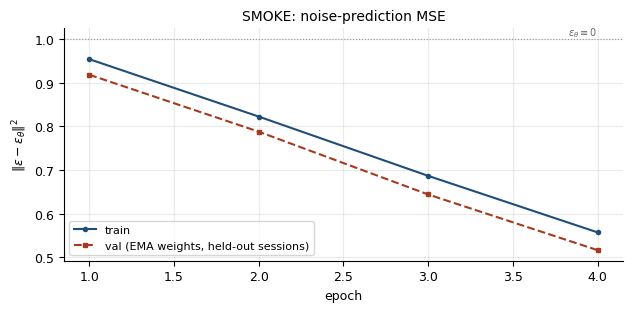

In [21]:
"""The loss curve. An untrained net predicts epsilon = 0, so the loss starts at ~1.0."""
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ep = np.arange(1, len(history.train_loss) + 1)
ax.plot(ep, history.train_loss, "o-", ms=3, color="#1f4e79", label="train")
if history.val_loss:
    ax.plot(ep[:len(history.val_loss)], history.val_loss, "s--", ms=3, color="#a33b20",
            label="val (EMA weights, held-out sessions)")
ax.axhline(1.0, color="0.6", lw=0.8, ls=":")
ax.text(ep[-1], 1.0, "  $\\epsilon_\\theta \\equiv 0$", va="bottom", ha="right", fontsize=7, color="0.4")
ax.set_xlabel("epoch"); ax.set_ylabel(r"$\|\epsilon - \epsilon_\theta\|^2$")
ax.set_title(f"{cfg.name}: noise-prediction MSE", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 9. Sampling: running the chain backwards

The true posterior $q(x_{t-1} \mid x_t, x_0)$ is Gaussian, with

$$\tilde\mu(x_t, x_0) = \frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}x_0
 + \frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}x_t,
\qquad
\tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t .$$

At sampling time we do not have $x_0$ — but the forward identity rearranges to
$x_0 = (x_t - \sqrt{1-\bar\alpha_t}\,\epsilon)/\sqrt{\bar\alpha_t}$, so predicting $\epsilon$
*is* predicting $x_0$. Substituting collapses the whole thing to the one line the sampler
actually runs:

$$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta(x_t, t)\right),
\qquad x_{t-1} = \mu_\theta + \sqrt{\tilde\beta_t}\, z, \quad z \sim \mathcal N(0, I).$$

The last step, $t = 0$, is deterministic: $\tilde\beta_0 = 0$ by construction, because
$\bar\alpha_{-1} = 1$.

The strip below draws this chain. With a well-trained $\epsilon_\theta$ it is where you watch
noise resolve into wavelet structure. Under `SMOKE` it is where you watch the chain *diverge*
instead — which is why every panel is annotated with its own standard deviation, and why each is
drawn on its own colour scale. Read those numbers rather than the colours; §11 explains them.

In [22]:
"""The reverse process, written out. Mirrors src/diffmodel/ddpm.py."""


def _randn(shape, device, generator=None, like=None):
    """Gaussian noise, from an explicit generator when one is supplied.

    A CPU `torch.Generator` cannot drive `randn` on an MPS/CUDA tensor, so the draw happens on
    the generator's device and is moved. Determinism is the point of that path; the copy is
    irrelevant at this scale. `generator=None` keeps the old process-global-RNG behaviour.
    """
    dtype = like.dtype if like is not None else None
    if generator is None:
        return torch.randn(shape, device=device, dtype=dtype)
    return torch.randn(shape, generator=generator, device=generator.device,
                       dtype=dtype).to(device)


@torch.no_grad()
def p_sample_step(model, x, t_index, sched, x0_clamp=None, generator=None):
    """One reverse step, x_t -> x_{t-1}, in the x0-hat parameterisation.

    Instead of the epsilon-form mean 1/sqrt(alpha_t) * (x - beta_t/sqrt(1-abar_t) * eps), make
    the model's implied clean image explicit,

        x0_hat = (x - sqrt(1 - abar_t) * eps_theta) / sqrt(abar_t)

    and feed it to the true posterior mean with its standard coefficients. Substituted
    unclamped the two are the same line of algebra — the cell below asserts that against src.

    The re-arrangement exists so the clamp has something to bite on. x0_hat is a statement
    about the clean data, so it can be bounded by what clean data looks like (config's
    `x0_clamp`, the observed image range); eps is legitimately N(0, I) and cannot be. Section
    11 shows what the chain does without it.
    """
    t = torch.full((x.shape[0],), t_index, device=x.device, dtype=torch.long)
    sqrt_ab = _gather(sched.sqrt_alphas_cumprod, t, x.ndim)
    sqrt_omab = _gather(sched.sqrt_one_minus_alphas_cumprod, t, x.ndim)

    x0_hat = (x - sqrt_omab * model(x, t)) / sqrt_ab
    if x0_clamp is not None:
        x0_hat = x0_hat.clamp(-x0_clamp, x0_clamp)

    c1 = _gather(sched.posterior_mean_coef1, t, x.ndim)
    c2 = _gather(sched.posterior_mean_coef2, t, x.ndim)
    mean = c1 * x0_hat + c2 * x
    if t_index == 0:
        return mean                     # final step is deterministic; beta~_0 = 0
    var = _gather(sched.posterior_variance, t, x.ndim)
    return mean + torch.sqrt(var) * _randn(x.shape, x.device, generator, like=x)


@torch.no_grad()
def sample(model, shape, sched, device, return_trajectory=False, progress=False,
           x0_clamp=None, generator=None):
    """Run the full reverse chain from pure noise.

    `return_trajectory` keeps ~12 evenly spaced intermediates, which is what the denoising
    strip below is drawn from. `generator` makes the chain reproducible without touching
    process-global RNG state, and `x0_clamp` is the safety net described above.
    """
    model.eval()
    x = _randn(shape, device, generator)
    T = len(sched)
    keep = set(range(T - 1, -1, -max(1, T // 12))) | {0}
    traj = []

    steps = range(T - 1, -1, -1)
    for i in steps:
        x = p_sample_step(model, x, i, sched, x0_clamp=x0_clamp, generator=generator)
        if return_trajectory and i in keep:
            traj.append(x.detach().cpu().clone())

    return (x, traj) if return_trajectory else x


In [23]:
"""Generate. The pictures below come from the INLINE sampler above; the assertion in this
cell is what entitles us to also call it `ddpm.sample`."""
N_GEN = 64

# Both samplers take an explicit `generator`, so nothing here touches the global torch RNG.
# The stream is derived from a LABEL rather than from ROOT_SEED's digits: seeding.py exists
# so that this draw stays independent of the training shuffle and of every other draw here.
# A fresh generator per call, same label, same stream.
def sampler_rng():
    return torch_generator("nb-sampler")


# --- faithful-mirror check, on CPU so the RNG stream is unambiguous ---
check_model = copy.deepcopy(ema.shadow).to("cpu")
check_sched = sched_cpu
a = sample(check_model, (2, *cfg.image_shape), check_sched, torch.device("cpu"),
           x0_clamp=cfg.x0_clamp, generator=sampler_rng())
b = src_ddpm.sample(check_model, (2, *cfg.image_shape), check_sched, torch.device("cpu"),
                    x0_clamp=cfg.x0_clamp, generator=sampler_rng())
assert torch.equal(a, b), "inline sampler and ddpm.sample diverge"
print("inline == src/diffmodel/ddpm.py  (sampler bit-identical under a labelled generator)")
del check_model

# --- the real draw, with the trajectory kept for the denoising strip ---
gen_images, traj = sample(ema.shadow, (N_GEN, *cfg.image_shape), sched, device,
                          return_trajectory=True, x0_clamp=cfg.x0_clamp,
                          generator=sampler_rng())
gen_images = gen_images.detach().cpu().numpy().astype(np.float64)
t_kept = sorted(set(range(cfg.timesteps - 1, -1, -max(1, cfg.timesteps // 12))) | {0}, reverse=True)
# No wall clock in this line on purpose: it is stored output, and CLAUDE.md non-negotiable
# #4 asks that a seeded re-execution reproduce this file byte for byte.
print(f"\n{N_GEN} sessions sampled: {cfg.timesteps} reverse steps on {device}, "
      f"trajectory has {len(traj)} frames")
print(f"generated image tensor: std {gen_images.std():.3f}, range "
      f"[{gen_images.min():.2f}, {gen_images.max():.2f}]")
print(f"real training images  : std {train_images.std():.3f}, range "
      f"[{train_images.min():.2f}, {train_images.max():.2f}]")
print(f"x0_clamp = {cfg.x0_clamp} (config); without it this chain reaches std ~7e2 — §11")


inline == src/diffmodel/ddpm.py  (sampler bit-identical under a labelled generator)

64 sessions sampled: 50 reverse steps on mps, trajectory has 14 frames
generated image tensor: std 4.311, range [-6.50, 6.50]
real training images  : std 0.333, range [-6.35, 6.35]
x0_clamp = 6.5 (config); without it this chain reaches std ~7e2 — §11


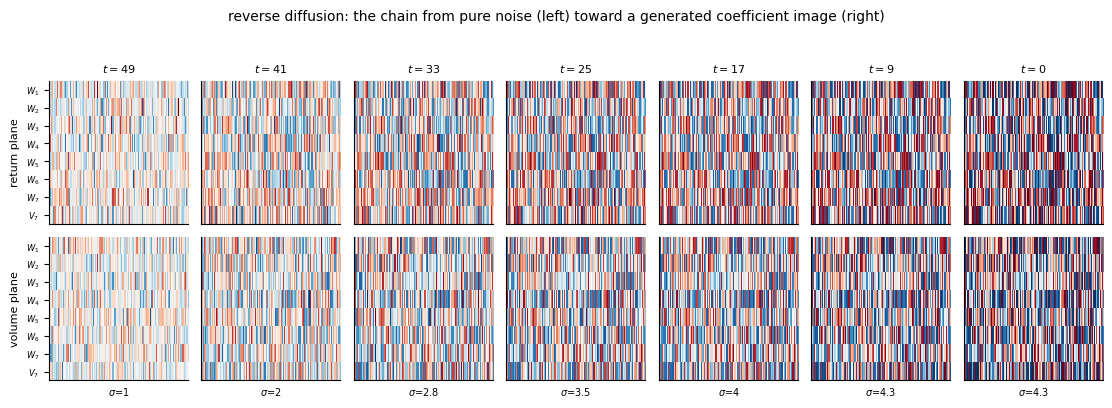

sigma along the chain: 1.03 -> 1.97 -> 2.83 -> 3.53 -> 4.01 -> 4.27 -> 4.29
final sigma is 13x the training-image scale (0.333): the chain DIVERGED rather than resolving.
That is the expected SMOKE outcome and section 11 measures exactly why. It is not a bug in the sampler,
which is verified against an exact epsilon there.


In [24]:
"""The denoising strip: the reverse chain, panel by panel.

Each panel gets its OWN colour scale, and its standard deviation is printed underneath,
because that scale is itself a diagnostic -- see section 11.
"""
picks = np.unique(np.linspace(0, len(traj) - 1, 7).astype(int))
fig, axes = plt.subplots(2, len(picks), figsize=(1.6 * len(picks), 3.9))
for col, k in enumerate(picks):
    arr = traj[k][0].numpy()
    lim = max(float(np.abs(arr).max()), 1e-12)
    axes[0, col].imshow(arr[0], aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim,
                        interpolation="nearest")
    axes[1, col].imshow(arr[2], aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim,
                        interpolation="nearest")
    axes[0, col].set_title(f"$t={t_kept[k]}$", fontsize=8)
    axes[1, col].set_xlabel(f"$\\sigma$={arr.std():.2g}", fontsize=7)
    for r in (0, 1):
        axes[r, col].set_xticks([]); axes[r, col].grid(False)
        axes[r, col].set_yticks(range(IMAGE_ROWS) if col == 0 else [])
        if col == 0:
            axes[r, col].set_yticklabels(row_labels, fontsize=6)
axes[0, 0].set_ylabel("return plane", fontsize=8)
axes[1, 0].set_ylabel("volume plane", fontsize=8)
fig.suptitle("reverse diffusion: the chain from pure noise (left) toward a generated "
             "coefficient image (right)", y=1.03, fontsize=10)
fig.tight_layout()
plt.show()

# Each panel is drawn on its own colour scale, so the colours alone cannot tell you whether the
# chain converged. The standard deviations can, and they are preset-independent.
ratio = gen_images.std() / train_images.std()
print(f"sigma along the chain: " + " -> ".join(f"{traj[k][0].numpy().std():.3g}" for k in picks))
if ratio > 3:
    print(f"final sigma is {ratio:.0f}x the training-image scale ({train_images.std():.3f}): the "
          f"chain DIVERGED rather than resolving.\nThat is the expected SMOKE outcome and section "
          f"11 measures exactly why. It is not a bug in the sampler,\nwhich is verified against an "
          f"exact epsilon there.")
else:
    print(f"final sigma is {ratio:.2f}x the training-image scale ({train_images.std():.3f}): "
          f"on-scale, so the chain resolved.")

## 10. Decoding back to price space

`Codec.decode` runs section 5 backwards, exactly:

$$\text{image} \ \xrightarrow{\ \text{invert level stats}\ }\ \text{planes}
 \ \xrightarrow{\ \text{iMODWT}\ }\ \text{padded series}
 \ \xrightarrow{\ \text{drop columns } 78..127\ }\ \text{normalised series}
 \ \xrightarrow{\ \text{sign}(z)|z|^{p},\ \sinh\ }\ \text{returns, spread, volume.}$$

One guard sits in that last arrow and needs stating, because it changes how the plots below
should be read. A trained model's output is unbounded, and the decoder's inverses are
$\operatorname{sign}(z)|z|^{1.5}$ and $\sinh$ — both explosive. $\sinh$ overflows float64
around $z = 710$, so a *single* wild pixel would turn generated volume into `inf`, then `nan`
on the first mean, and every downstream metric would silently become `nan`.

So the decoder clamps its input at $\pm 10\sigma$, symmetrically with the winsorisation the
encoder applies. The encoder can never emit a value outside that bound, so the decoder should
never be asked to invert one. **`saturated_report` says how often the clamp actually fires,
and that number is reported below rather than swallowed** — a model producing many
out-of-range pixels shows up as a saturated distribution instead of as `nan`, which is the
difference between a visible failure and an invisible one.

In [25]:
"""Decode the generated images, and say plainly how much of the result hit the clamp."""
gen_series = codec.decode(gen_images)                       # (N_GEN, 3, 78)
real_series = val_meta.series                               # held-out sessions

decoder_input = src_wavelet.image_to_series(
    invert_level_stats(gen_images, codec.level_stats, codec.image_scale), BARS_PER_DAY)
sat = day_transform.saturated_report(decoder_input)
sat_real = day_transform.saturated_report(day_transform.forward(real_series))

print("fraction of decoder inputs hitting the +/-10 sigma clamp")
print(f"  {'channel':<10s} {'generated':>10s} {'real (held-out)':>18s}")
for k in sat:
    print(f"  {k:<10s} {sat[k]:>10.2%} {sat_real[k]:>18.2%}")

print(f"\n{'channel':<16s} {'generated':>27s} {'real (held-out)':>29s}")
for i, name in enumerate(CH_NAMES):
    g_, r_ = gen_series[:, i], real_series[:, i]
    print(f"{name:<16s} std {g_.std():>11.4g} kurt {ev.excess_kurtosis(g_):>8.1f}"
          f"   std {r_.std():>11.4g} kurt {ev.excess_kurtosis(r_):>8.1f}")

fraction of decoder inputs hitting the +/-10 sigma clamp
  channel     generated    real (held-out)
  returns        19.31%              0.00%
  spread          1.80%              0.08%
  volume          0.00%              0.00%

channel                            generated               real (held-out)
log return       std      0.0325 kurt     -0.8   std     0.00213 kurt     65.7
spread (h-l)/c   std     0.01149 kurt     -0.5   std    0.002825 kurt    231.9
volume           std   2.036e+08 kurt   3612.1   std   2.331e+05 kurt    244.1


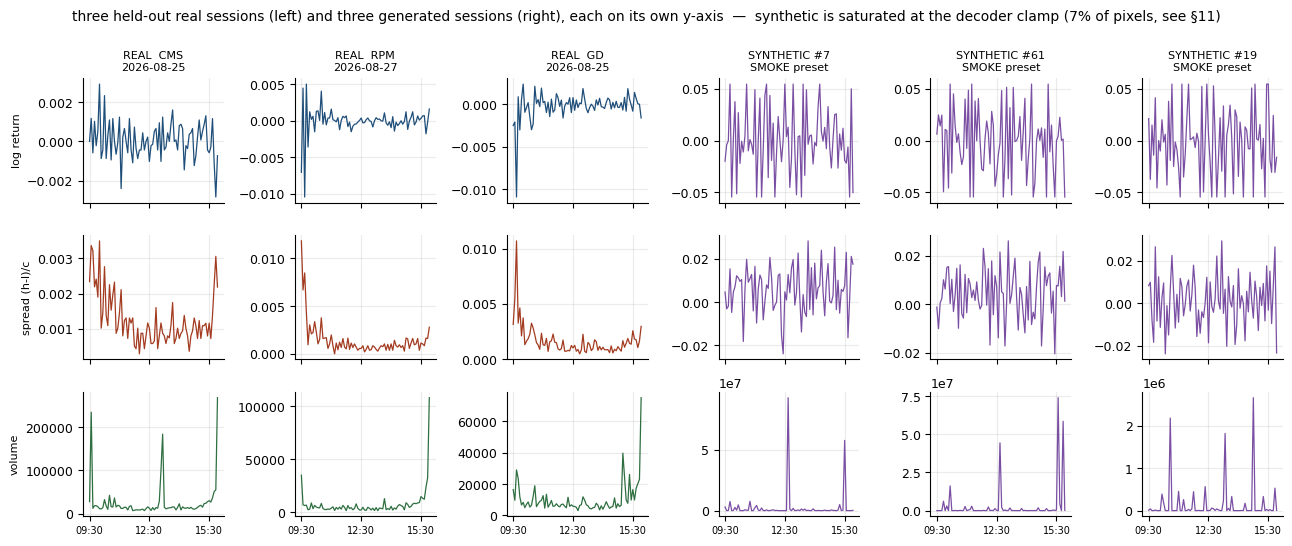

In [26]:
"""Synthetic days beside real days, all three channels."""
rng_show = fork("nb-show-days")
n_show = 3
real_idx = rng_show.choice(len(real_series), size=n_show, replace=False)
gen_idx = rng_show.choice(len(gen_series), size=n_show, replace=False)

fig, axes = plt.subplots(3, 2 * n_show, figsize=(13.0, 5.4), sharex=True)
for col in range(n_show):
    for row, (name, color) in enumerate(zip(CH_NAMES, CH_COLORS)):
        axes[row, col].plot(clock, real_series[real_idx[col], row], color=color, lw=0.9)
        axes[row, n_show + col].plot(clock, gen_series[gen_idx[col], row], color="#7a4fa3", lw=0.9)
    axes[0, col].set_title(f"REAL  {val_meta.tickers[real_idx[col]]}\n{val_meta.sessions[real_idx[col]]}",
                           fontsize=8)
    axes[0, n_show + col].set_title(f"SYNTHETIC #{gen_idx[col]}\n{cfg.name} preset", fontsize=8)
for row, name in enumerate(CH_NAMES):
    axes[row, 0].set_ylabel(name, fontsize=8)
for ax in axes[2]:
    ax.set_xticks([9.5, 12.5, 15.5]); ax.set_xticklabels(["09:30", "12:30", "15:30"], fontsize=7)
sat_note = (f"  —  synthetic is saturated at the decoder clamp "
            f"({np.mean(list(sat.values())):.0%} of pixels, see §11)"
            if np.mean(list(sat.values())) > 0.05 else "")
fig.suptitle("three held-out real sessions (left) and three generated sessions (right), "
             f"each on its own y-axis{sat_note}", y=1.0, fontsize=10)
fig.tight_layout()
plt.show()

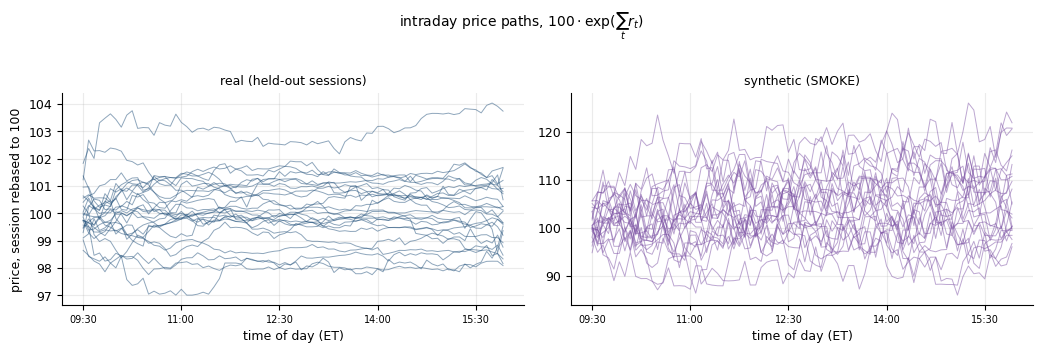

In [27]:
"""Price space: cumulative log returns, which is what a trader would actually look at."""
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4), sharey=False)
n_paths = 24
for ax, series, title, color in [
    (axes[0], real_series[fork("nb-paths-real").choice(len(real_series), n_paths, replace=False)],
     "real (held-out sessions)", "#1f4e79"),
    (axes[1], gen_series[fork("nb-paths-gen").choice(len(gen_series), min(n_paths, len(gen_series)),
                                                    replace=False)],
     f"synthetic ({cfg.name})", "#7a4fa3"),
]:
    paths = 100.0 * np.exp(np.cumsum(series[:, 0], axis=1))
    ax.plot(clock, paths.T, color=color, lw=0.7, alpha=0.5)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([9.5, 11.0, 12.5, 14.0, 15.5])
    ax.set_xticklabels(["09:30", "11:00", "12:30", "14:00", "15:30"], fontsize=7)
    ax.set_xlabel("time of day (ET)")
axes[0].set_ylabel("price, session rebased to 100")
fig.suptitle("intraday price paths, $100 \\cdot \\exp(\\sum_t r_t)$", y=1.02, fontsize=10)
fig.tight_layout()
plt.show()

In [28]:
"""The stylized facts, as numbers. Notebook 02 does this properly across every baseline;
this is the honest one-line version so section 11's claim is checkable here."""
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    real_facts = ev.StylizedFacts.measure(real_series)
    gen_facts = ev.StylizedFacts.measure(gen_series)
    dist = ev.compare(real_facts, gen_facts)

print(f"{'stylized fact':<26s} {'real (held-out)':>16s} {'synthetic':>12s}")
for label, r, s in [
    ("Hill alpha (pooled)", real_facts.tail_index, gen_facts.tail_index),
    ("Hill alpha (within-day)", real_facts.tail_index_within, gen_facts.tail_index_within),
    ("excess kurtosis", real_facts.kurtosis, gen_facts.kurtosis),
    ("vol dispersion", real_facts.vol_dispersion, gen_facts.vol_dispersion),
    ("ACF |r| lag 1", real_facts.acf_abs[0], gen_facts.acf_abs[0]),
    ("ACF r lag 1", real_facts.acf_raw[0], gen_facts.acf_raw[0]),
    ("intraday |r|, open bar", real_facts.intraday_vol[0], gen_facts.intraday_vol[0]),
    ("intraday volume, close bar", real_facts.intraday_volume[-1], gen_facts.intraday_volume[-1]),
    ("corr(|r|, volume)", real_facts.cross_corr[0, 2], gen_facts.cross_corr[0, 2]),
]:
    print(f"{label:<26s} {r:>16.3f} {s:>12.3f}")

print(f"\n{'distance (0 = perfect)':<26s}")
for k, v in dist.items():
    print(f"  {k:<32s} {v:>10.3f}")

if not np.isfinite(gen_facts.tail_index):
    print("\nThe NaN is informative, not a defect: the Hill estimator divides by the mean of")
    print("log(x_(i) / x_(k)) over the tail, and when every tail value is the SAME number that")
    print("mean is exactly zero. Identical tail values are what a fully saturated decoder output")
    print("looks like -- so the NaN is the saturation reported two cells above, showing up again.")
print("\nThe 'real' column is the held-out split only (3 sessions), not the whole fixture, so it")
print("differs from the pooled figures in RESEARCH.md. It is the right comparison here because it")
print("is data the model never saw.")

stylized fact               real (held-out)    synthetic
Hill alpha (pooled)                   2.232          nan
Hill alpha (within-day)               2.708       22.846
excess kurtosis                      65.741       -0.758
vol dispersion                        0.427        0.062
ACF |r| lag 1                         0.027       -0.020
ACF r lag 1                          -0.060       -0.333
intraday |r|, open bar                5.234        0.989
intraday volume, close bar            6.368        0.051
corr(|r|, volume)                     0.324        0.008

distance (0 = perfect)    
  tail_within_abs_err                  20.137
  vol_dispersion_rel_err                0.855
  tail_pooled_abs_err                     nan
  kurtosis_rel_err                      1.012
  acf_abs_l2                            0.019
  acf_decay_abs_err                       nan
  intraday_vol_mse                      0.478
  intraday_volume_mse                   9.414
  cross_corr_frobenius            

## 11. What this run does and does not show

### SMOKE output is expected to be poor. That is the design, not a disappointment.

`SMOKE` is not a toy code path — it is the *same* code with smaller numbers, so whatever runs
locally is exactly what Colab runs. Its job is to catch shape errors, $\bar\alpha$ indexing
bugs, wrong inverse transforms and NaN blowups. Its job is **not** to produce good samples,
and the table above should not be read as though it were a result.

What this run *does* establish, and each of these is an executed assertion above rather than
a claim:

- the geometry agrees with `config.py` — 78 bars, 128 padded, 8 planes, $3\times8\times128$;
- the Haar MODWT inverts to $< 10^{-10}$ on real data, on white noise, and at every level
  count from 1 to 7; the planes sum back to the signal; the transform is shift-equivariant;
- the notebook's hand-built encode pipeline — its own date split, its own fitted
  `DayTransform`, its own level statistics, its own inline MODWT — is *bit-identical* to
  `pipeline.prepare()`;
- every inline block agrees bit-for-bit with its `src/diffmodel` counterpart — transform,
  wavelet, schedule, `q_sample`, UNet weights and forward pass, `p_losses` at all three loss
  types, the EMA shadow after four updates, the validation loss, and the sampler. The single
  exception is the epoch loop of §8, which would have to be trained twice to compare and is
  checked through its parts instead;
- the forward chain reaches $\mathcal N(0, I)$ under the schedule this preset actually uses;
- the UNet's shapes are what §1a predicted, and it emits $\epsilon$ at the input shape;
- the loss falls, the reverse chain runs end to end, and the result decodes to finite
  numbers — the single `nan` in the fact table is the Hill estimator dividing by zero on a
  *saturated* tail, which is the clamp report two cells earlier showing up again, and it is
  explained where it appears rather than swallowed.

Two things those outputs are *not*. First, they are **not reproducible from a clean clone**.
`checkpoints/` is gitignored, so §8 loads a local checkpoint on this machine and trains from
scratch on a fresh one; the loss curve, the samples and every number downstream of them will
differ there. Re-executing this file on a machine that holds the same checkpoint reproduces
it byte for byte — the recipe is at the top.

Second, they are **not evidence about sample quality, and no claim about it should be made
from this run.** Those claims require the `FULL` Colab run — 100 epochs, all ~22k images,
$T = 1000$ linear, 128 base channels — and they belong in
`02_baselines_and_scorecard.ipynb`, scored against the classical and GAN baselines rather
than eyeballed.

### Why the SMOKE samples fail the way they do, specifically

It is worth being precise about the failure mode rather than waving at "undertrained",
because the mechanism is legible and it is a property of the *preset*, not of the method.

The reverse step multiplies the running state by $1/\sqrt{\alpha_t}$ and the network's
$\epsilon$ **error** by $\beta_t / (\sqrt{\alpha_t}\sqrt{1-\bar\alpha_t})$. Cosine at
$T=50$ is what makes the forward chain actually reach pure noise (§6) — and it is also what
makes the *first* reverse steps ill-conditioned, because $\bar\alpha$ is driven to $\sim
10^{-3}$ in fifty steps and the per-step $\beta$ saturates its clip. An $\epsilon$ predictor
that is merely good rather than exact has its residual amplified, and the chain walks away
from the data manifold.

An earlier version of this notebook clipped $\beta$ at $0.9999$, which allows $\alpha_t =
10^{-4}$ and so a **100×** state gain on the very first reverse step. Sampling this
checkpoint under that schedule produced an image-space std of $1.9\times10^3$ against a real
$0.333$, and 99.8% of decoded values were pinned to the $\pm10\sigma$ winsorisation clamp —
the scorecard's DDPM row was measuring saturation, not a model. Two changes, in order of
importance:

1. **the $\hat x_0$ clamp** (§9, `config.x0_clamp = 6.5`). Each reverse step now makes the
   implied clean image explicit and bounds it to the observed data range ($\pm6.35$ on the
   fit split) before forming the posterior mean. This is the `clip_denoised` safety net the
   reference implementations carry, and it is what actually fixes the blow-up: std
   $1.9\times10^3 \to 4.3$;
2. **the $\beta$ clip at $0.999$**, aligning with Nichol & Dhariwal. On its own it is *not*
   sufficient — it brings the unclamped chain to std $\sim 7\times10^2$, still three orders
   too large — but it caps the first-step gain at $31.6$ rather than $100$.

std $4.3$ against a real $0.333$ is still an order of magnitude too wide; four epochs is four
epochs. The difference is that it now fails *bounded*, in a way the scorecard can measure.
The cell below measures both amplification factors for this run's schedule and for `FULL`'s,
and then samples the same checkpoint with and without the clamp.

In [29]:
"""How much this schedule amplifies a residual epsilon error, per step and in total."""
print(f"{'schedule':>16s}  {'max 1/sqrt(alpha_t)':>20s}  {'max eps-error gain':>19s}  "
      f"{'total 1/sqrt(abar_T)':>21s}")
for kind, T in [(cfg.beta_schedule, cfg.timesteps), ("linear", 1000)]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        s = DiffusionSchedule.build(T, kind=kind)
    state_gain = (1.0 / s.alphas.sqrt()).max().item()
    eps_gain = (s.betas / (s.alphas.sqrt() * s.sqrt_one_minus_alphas_cumprod)).max().item()
    total = (1.0 / s.alphas_cumprod[-1].sqrt()).item()
    tag = "  <- this run" if (kind, T) == (cfg.beta_schedule, cfg.timesteps) else "  <- FULL / Colab"
    print(f"{kind + ' T=' + str(T):>16s}  {state_gain:>20.4g}  {eps_gain:>19.4g}  {total:>21.4g}{tag}")

# The sampler itself is not what fails: with an EXACT epsilon it reconstructs x0 to machine
# precision. This isolates "the model is not accurate enough yet" from "the math is wrong",
# which are otherwise indistinguishable from a bad-looking plot.
x0_probe = torch.from_numpy(train_images[:4]).float()


class OracleEps(nn.Module):
    """Returns the epsilon that a perfect noise predictor would return for x0_probe."""

    def forward(self, x, t):
        a = _gather(sched_cpu.sqrt_alphas_cumprod, t, x.ndim)
        b = _gather(sched_cpu.sqrt_one_minus_alphas_cumprod, t, x.ndim)
        return (x - a * x0_probe) / b


oracle_out = sample(OracleEps(), x0_probe.shape, sched_cpu, torch.device("cpu"),
                    generator=torch_generator("nb-oracle"))
print(f"\nsampler driven by an EXACT epsilon: max |x_0 - sample| = "
      f"{(oracle_out - x0_probe).abs().max().item():.3e}")
print("  -> the reverse chain is correct; what is missing is epsilon accuracy, which is "
      "epochs and capacity,\n     i.e. exactly what the FULL Colab run supplies.")

# What the clamp is worth on THIS checkpoint: same weights, same schedule, same noise stream,
# one argument different. Without it the chain is not slightly worse, it is unusable.
probe = copy.deepcopy(ema.shadow).to("cpu")
for clamp in (cfg.x0_clamp, None):
    out = sample(probe, (16, *cfg.image_shape), sched_cpu, torch.device("cpu"),
                 x0_clamp=clamp, generator=torch_generator("nb-clamp-ablation"))
    print(f"x0_clamp={str(clamp):>4s}: sampled std {out.std().item():>9.4g}  "
          f"max |x| {out.abs().max().item():>9.4g}")
print(f"real images : std {train_images.std():>9.4g}  max |x| {abs(train_images).max():>9.4g}")
del probe

        schedule   max 1/sqrt(alpha_t)   max eps-error gain   total 1/sqrt(abar_T)
     cosine T=50                 31.62                31.59                   1015  <- this run
   linear T=1000                  1.01               0.0202                  157.4  <- FULL / Colab

sampler driven by an EXACT epsilon: max |x_0 - sample| = 1.490e-08
  -> the reverse chain is correct; what is missing is epsilon accuracy, which is epochs and capacity,
     i.e. exactly what the FULL Colab run supplies.
x0_clamp= 6.5: sampled std     4.307  max |x|       6.5
x0_clamp=None: sampled std     689.9  max |x|      3407
real images : std    0.3333  max |x|      6.35


### And once more, because it is the easiest thing to forget

The fixture is **60 trading sessions from a single 2026 summer**. Breadth across ~380 tickers
is not the same thing as history: every one of those names lived through the *same* macro
regime. Nothing in this notebook — at `SMOKE` scale or at `FULL` scale, with a perfect
scorecard or a terrible one — can speak to whether the generator would still work in a
crisis, a rate cycle, or a regime it never saw.

Cross-sectional stylized facts are testable here. Regime-robustness is not, and claiming it
would require a longer sample, not a better model.

---

**Next:** `02_baselines_and_scorecard.ipynb` — the same generated data scored against
classical (GARCH), no-wavelet-ablation, and GAN baselines. The no-wavelet ablation is the one
that tests the paper's actual claim: not "diffusion models can generate financial time
series", but "the *wavelet-image* representation beats operating on the raw series". Only
that comparison isolates the contribution.